# Wildlife Strike Damage Prediction - Team MPB 

## Project Overview:
This Jupyter Notebook documents our process in building a classifier to predict whether an aircraft wildlife strike causes on the dataset provided from the FAA from 1990-2015. We set out to use a tree-based ensembling method to adapt to the data's mixed and inconsistent character, and we initially tested Random Forests, but performed better with XGBoost, and also found it easier to work with. Our experiments proved to us that the ensembling methods could be a solid baseline, and we ran from there. We also focused on strategic feature engineering for categories we deemed most important based on our data analysis. There was substantial room for reflection on our methodology and what we could have done differently, which will come at the end!

## Overall Summary:
- First, we explored patterns in the strike data, with the goal of focusing our data analysis and cleaning to remove the noise and redundancy that existed in the dataset; even a brief look at the visualizations on Kaggle demonstrated how uneven it was. Based on what we discovered with our visualizations, we capped numeric data to remove the influence of outliers, removed statistically redundant features, and engineered new features such as bird size classifications and more useful time measurements.
-  We used a wide variety of methods for imputation and data manipulation, including using machine learning to predict, and also direct analysis of the kinds of birds provided, for example.
-  We trained XGBoost with class weighting to handle the extreme class inablance (sub 10% damage rate overall!)
-  Iterated on model parameters using cross-validation with balanced accuracy scaling


## What We Learned:
- Our initial pipeline overfit based on some issues with combined train/test encoding



## Notebook Structure:
1. Data Cleaning and Exploration
2. Feature Engineering
3. Model Training & Tuning
4. Results & Reflection

# Data Cleaning and Exploration
Here, we parsed dates, standardized our time formats, handled missing values with imputation and removal, and standardized missingness indicators. We parsed INCIDENT_DATE to extract incident_day and incident_weekday while preserving incident_year and incident_month where they existed, and also standardized time. We handled numeric conversion for latitude, longitude, height, and speed, and used median imputation in strategic places. We also added missing indicator columns, which we also addressed later to capture a wider variety of missing feature indicators. We generally standardized string fields to prevent leakage and to not complicate training; we extracted what we could from COMMENT, for example, such as simply the presence of it, without using NLP processing directly. We also treated fields like SPECIES, PHASE_OF_FLIGHT, SKY, and PRECIPITATION as categorical text as well. We also got rid of some noisy features like INDEX_NR (just a row identifier) or LUPDATE and TRANSFER which we deemed as being administrative metadata with no clear correlation to anything in a potential accident.

For our exploration, we analyzed the shape of the dataset, the distribution of the targets, and created several histograms/visaulizations to see categorical relationships, correlations for numeric features, and associations for categorical features as well. We identified key issues, such as the high missing rates in features like enginer position, or the presence of significant outliers in numerical data, in addition to the large categorical noise present in features like SPECIES or text fields. We gained an extremely important understanding of the distribution of the target values, of which features were particularly important (such as PHASE_OF_FLIGHT, SIZE, and SPECIES with high correlations w/ damage rates), and of temporal patterns and operational factors like mass and speed. This opened the door for some feature engineering and more data cleaning at the same time. This exploration phase was critical for transforming raw data into actionable insights, ensuring the modeling phase started with a well-understood, quality-assessed dataset.

### Some Early Decisions
As stated previously, we began to approach data cleaning and exploration with the mindset that we should make the job of our trees as easy and efficient as possible; while we were getting our feet wet looking at the data, we manipulated the data in the ways we thought would be most impactful overall. Making explicit discoveries about the distribution of the target values only reinforced our decision. We understood that the ensemble tree method we at least had decided on from the outset would be adaptable to an uneven dataset, but we did not want it to overfit to noise, either, and thought there was plenty of room to make informed and creative decisions.

### Initial Standardization
Here, we standardized the date features and made miscellaneo

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

#Splitting the data up by year/month/day instead of just the full numerical date.
#useful for things like potentially inferring seasons, etc.
def parse_date_features(df):
    df = df.copy()
    
    # Let pandas infer the datetime format to prevent silent 'coerce' failures
    df['INCIDENT_DATE'] = pd.to_datetime(df['INCIDENT_DATE'], errors='coerce') 
    
    # Extract features (added year and month as they are very useful for this dataset!)
    df['incident_year'] = df['INCIDENT_DATE'].dt.year
    df['incident_month'] = df['INCIDENT_DATE'].dt.month
    df['incident_day'] = df['INCIDENT_DATE'].dt.day
    df['incident_weekday'] = df['INCIDENT_DATE'].dt.weekday
    
    return df

''' 
Method to parse amd handle a variety of features.
'''
def clean_wildlife_strike_df(df, is_train=True):
    df = df.copy()
    df.columns = df.columns.str.strip()
    df = parse_date_features(df)

    #Make a boolean marker for whether a comment exists or not, rather than based on the content
    remark_col = None
    if 'REMARKS' in df.columns:
        remark_col = 'REMARKS'
    elif 'COMMENTS' in df.columns:
        remark_col = 'COMMENTS'
    
    if remark_col:
        # Flag: 1 if there's actual content, 0 if empty/null/Unknown
        df['HAS_COMMENT'] = (
            df[remark_col].notna() & 
            (df[remark_col].astype(str).str.strip() != '') &
            (df[remark_col].astype(str).str.lower() != 'nan') &
            (df[remark_col].astype(str).str.lower() != 'unknown')
        ).astype(int)
        
        print(f"{'Train' if is_train else 'Test'} - HAS_COMMENT: {df['HAS_COMMENT'].sum()} rows ({df['HAS_COMMENT'].mean()*100:.2f}%)")
    else:
        df['HAS_COMMENT'] = 0  # No comment column exists
        print(f"{'Train' if is_train else 'Test'} - No comment column found, HAS_COMMENT set to 0")

    # Standardize time
    df['TIME'] = df['TIME'].astype(str).str.strip().replace({'nan': np.nan, '': np.nan})
    df['incident_hour'] = pd.to_datetime(df['TIME'], format='%H:%M', errors='coerce').dt.hour
    df['incident_minute'] = pd.to_datetime(df['TIME'], format='%H:%M', errors='coerce').dt.minute
    df['TIME_OF_DAY'] = df['TIME_OF_DAY'].astype(str).str.strip().replace({'nan': 'Unknown', '': 'Unknown'})

    # Numeric conversion + missing indicators
    numeric_cols = [
        'LATITUDE', 'LONGITUDE', 'AMA', 'AMO', 'EMA', 'EMO',
        'AC_MASS', 'NUM_ENGS', 'ENG_1_POS', 'ENG_2_POS',
        'ENG_3_POS', 'ENG_4_POS', 'HEIGHT', 'SPEED', 'DISTANCE',
        'NUM_SEEN', 'NUM_STRUCK'
    ]
    for col in numeric_cols:
        if col in df.columns:
            df[col] = pd.to_numeric(df[col], errors='coerce')
            df[f'{col}_missing'] = df[col].isna().astype(int)
            df[col] = df[col].fillna(df[col].median())

    # Categorical cleaning
    cat_cols = [
        'TIME_OF_DAY', 'AIRPORT_ID', 'STATE', 'OPID', 'OPERATOR',
        'REG', 'AIRCRAFT', 'AC_CLASS', 'TYPE_ENG', 'PHASE_OF_FLIGHT',
        'SKY', 'PRECIPITATION', 'BIRD_BAND_NUMBER', 'SPECIES_ID',
        'SPECIES', 'OUT_OF_RANGE_SPECIES', 'ENROUTE_STATE',
        'SOURCE', 'PERSON'
    ]
    for col in cat_cols:
        if col in df.columns:
            df[col] = df[col].fillna('Unknown').astype(str).str.strip()
            df[col] = df[col].where(df[col] != '', 'Unknown')

    # Binary / ordinal cleanup
    if 'REMAINS_COLLECTED' in df.columns:
        df['REMAINS_COLLECTED'] = pd.to_numeric(df['REMAINS_COLLECTED'], errors='coerce').fillna(0).astype(int)
    if 'REMAINS_SENT' in df.columns:
        df['REMAINS_SENT'] = pd.to_numeric(df['REMAINS_SENT'], errors='coerce').fillna(0).astype(int)
    if 'WARNED' in df.columns:
        mapping = {'Yes': 1, 'No': 0, 'Unknown': -1, 'nan': -1, '': -1}
        warned_clean = df['WARNED'].astype(str).str.strip().map(mapping).fillna(-1).astype(int)
        df['WARNED'] = warned_clean

    # Target cleanup if necessary
    if 'INDICATED_DAMAGE' in df.columns:
        df['INDICATED_DAMAGE'] = pd.to_numeric(df['INDICATED_DAMAGE'], errors='coerce').astype('Int64')

    #dropping noisy/text-heavy columns, like comments
    drop_cols = [
        'INDEX_NR', 'INCIDENT_DATE', 'LOCATION', 'AIRPORT', 'REMARKS',
        'COMMENTS', 'LUPDATE', 'TRANSFER', 'FAAREGION'
    ]
    drop_cols = [c for c in drop_cols if c in df.columns]
    df = df.drop(columns=drop_cols)

    return df


train = pd.read_csv('train.csv', low_memory=False)
test = pd.read_csv('test.csv', low_memory=False)


#train_clean and test_clean are the sets that we progressively change throughout the notebook
train_clean = clean_wildlife_strike_df(train, is_train=True)
test_clean = clean_wildlife_strike_df(test, is_train=False)

C:\Users\sebia\AppData\Local\Temp\ipykernel_31536\1125553622.py:11: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  df['INCIDENT_DATE'] = pd.to_datetime(df['INCIDENT_DATE'], errors='coerce')


Train - HAS_COMMENT: 271871 rows (88.51%)


C:\Users\sebia\AppData\Local\Temp\ipykernel_31536\1125553622.py:11: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  df['INCIDENT_DATE'] = pd.to_datetime(df['INCIDENT_DATE'], errors='coerce')


Test - HAS_COMMENT: 30276 rows (88.71%)


In [3]:

# Preview the cleaned dataset - check if anything stands out
print('Cleaned training dataset shape:', train_clean.shape)
print('\nCleaned columns:')
print(train_clean.columns.tolist())
print('\nSample rows from cleaned training data:')
display(train_clean.head())
print('\nMissing values after cleaning:')
print(train_clean.isna().sum().sort_values(ascending=False).head(20))

Cleaned training dataset shape: (307178, 70)

Cleaned columns:
['INCIDENT_MONTH', 'INCIDENT_YEAR', 'TIME', 'TIME_OF_DAY', 'AIRPORT_ID', 'LATITUDE', 'LONGITUDE', 'RUNWAY', 'STATE', 'OPID', 'OPERATOR', 'REG', 'FLT', 'AIRCRAFT', 'AMA', 'AMO', 'EMA', 'EMO', 'AC_CLASS', 'AC_MASS', 'TYPE_ENG', 'NUM_ENGS', 'ENG_1_POS', 'ENG_2_POS', 'ENG_3_POS', 'ENG_4_POS', 'PHASE_OF_FLIGHT', 'HEIGHT', 'SPEED', 'DISTANCE', 'SKY', 'PRECIPITATION', 'BIRD_BAND_NUMBER', 'SPECIES_ID', 'SPECIES', 'OUT_OF_RANGE_SPECIES', 'REMAINS_COLLECTED', 'REMAINS_SENT', 'WARNED', 'NUM_SEEN', 'NUM_STRUCK', 'SIZE', 'ENROUTE_STATE', 'SOURCE', 'PERSON', 'INDICATED_DAMAGE', 'incident_year', 'incident_month', 'incident_day', 'incident_weekday', 'HAS_COMMENT', 'incident_hour', 'incident_minute', 'LATITUDE_missing', 'LONGITUDE_missing', 'AMA_missing', 'AMO_missing', 'EMA_missing', 'EMO_missing', 'AC_MASS_missing', 'NUM_ENGS_missing', 'ENG_1_POS_missing', 'ENG_2_POS_missing', 'ENG_3_POS_missing', 'ENG_4_POS_missing', 'HEIGHT_missing', 'S

,INCIDENT_MONTH,INCIDENT_YEAR,TIME,TIME_OF_DAY,AIRPORT_ID,LATITUDE,LONGITUDE,RUNWAY,STATE,OPID,...,NUM_ENGS_missing,ENG_1_POS_missing,ENG_2_POS_missing,ENG_3_POS_missing,ENG_4_POS_missing,HEIGHT_missing,SPEED_missing,DISTANCE_missing,NUM_SEEN_missing,NUM_STRUCK_missing
0,12,1993,NaN,Day,TJSJ,18.439420,-66.001830,7,PR,AAL,...,0,0,0,0,1,0,0,1,1,1
1,2,2010,5:00,Night,WMKK,2.745578,101.709917,32R,FN,FDX,...,0,0,0,0,1,0,1,0,1,0
2,5,2012,2:00,Night,KSDF,38.174390,-85.736000,35L,KY,UPS,...,0,0,0,1,1,0,0,0,1,0
3,10,2002,NaN,Unknown,KLAX,33.942540,-118.408070,25R,CA,UNK,...,1,1,1,1,1,1,1,0,1,1
4,2,1997,NaN,Dawn,PHLI,21.975980,-159.338960,35,HI,1AAH,...,0,0,0,1,1,0,0,0,0,0



Missing values after cleaning:
FLT                161435
TIME               132042
incident_hour      132042
incident_minute    132042
RUNWAY              75585
SIZE                33507
LATITUDE                0
AIRPORT_ID              0
TIME_OF_DAY             0
INCIDENT_YEAR           0
INCIDENT_MONTH          0
OPID                    0
STATE                   0
LONGITUDE               0
AMA                     0
AMO                     0
EMA                     0
EMO                     0
AC_CLASS                0
OPERATOR                0
dtype: int64


### Numeric Feature Analysis
We then decided that the numeric values would be of massive importance to this dataset, as they provided a lot of room for inference based on what was probably a physics-based scenario. Particular values seemed very important logically: values like height, speed, and distance seemed absolutely necessary for tuning the model off the bat. The numeric values seemed like the strongest place to look for relationships at first glance, and we wanted to help our models find those relationships more easily, but also ourselves. We looked for the most skewed numeric data that we could check based on a 1.5x IQR rule. After our first boxplots, we realized that our visualizations were very skewed too, so we thought to kill two birds with one stone.

In [ ]:

#We explicitly labeled every single numeric feature for easier analysis
numeric_outlier_cols = [
    'HEIGHT', 'SPEED', 'DISTANCE', 'LATITUDE', 'LONGITUDE',
    'AMA', 'AMO', 'EMA', 'EMO', 'AC_MASS', 'NUM_ENGS',
    'ENG_1_POS', 'ENG_2_POS', 'ENG_3_POS', 'ENG_4_POS',
    'NUM_SEEN', 'NUM_STRUCK'
]
numeric_outlier_cols = [c for c in numeric_outlier_cols if c in train_clean.columns]

outlier_rows = []
for col in numeric_outlier_cols:
    values = train_clean[col].dropna()
    q1, q3 = np.percentile(values, [25, 75])
    iqr = q3 - q1
    lower, upper = q1 - 1.5 * iqr, q3 + 1.5 * iqr
    outliers = values[(values < lower) | (values > upper)]
    outlier_rows.append((col, len(outliers), len(values), lower, upper))

#1.5 times above or below the IQR we specified before
print('Outlier detection summary (1.5*IQR rule):')
for col, count, total, lower, upper in outlier_rows:
    print(f'{col}: {count} outliers out of {total} ({count/total*100:.2f}%), bounds=({lower:.2f}, {upper:.2f})')


# Visualize boxplots for key numeric fields
plot_cols = [c for c in ['HEIGHT', 'SPEED', 'DISTANCE'] if c in train_clean.columns]
if plot_cols:
    fig, axes = plt.subplots(len(plot_cols), 1, figsize=(10, 4 * len(plot_cols)))
    if len(plot_cols) == 1:
        axes = [axes]
    for ax, col in zip(axes, plot_cols):
        ax.boxplot(train_clean[col].dropna(), vert=False, patch_artist=True,
                   boxprops=dict(facecolor='lightblue', color='black'),
                   medianprops=dict(color='red'))
        ax.set_title(f'Boxplot of {col}')
        ax.set_xlabel(col)
    plt.tight_layout()
    plt.show()


Outlier detection summary (1.5*IQR rule):
HEIGHT: 147239 outliers out of 307178 (47.93%), bounds=(50.00, 50.00)
SPEED: 0 outliers out of 307178 (0.00%), bounds=(140.00, 140.00)
DISTANCE: 0 outliers out of 307178 (0.00%), bounds=(0.00, 0.00)
LATITUDE: 11309 outliers out of 307178 (3.68%), bounds=(23.06, 51.27)
LONGITUDE: 28192 outliers out of 307178 (9.18%), bounds=(-121.04, -57.75)
AMA: 58011 outliers out of 307178 (18.89%), bounds=(88.00, 248.00)
AMO: 44214 outliers out of 307178 (14.39%), bounds=(-3.50, 40.50)
EMA: 2243 outliers out of 307178 (0.73%), bounds=(-8.00, 40.00)
EMO: 62155 outliers out of 307178 (20.23%), bounds=(-3.50, 8.50)
AC_MASS: 0 outliers out of 307178 (0.00%), bounds=(4.00, 4.00)
NUM_ENGS: 0 outliers out of 307178 (0.00%), bounds=(2.00, 2.00)
ENG_1_POS: 0 outliers out of 307178 (0.00%), bounds=(-3.50, 8.50)
ENG_2_POS: 0 outliers out of 307178 (0.00%), bounds=(-3.50, 8.50)
ENG_3_POS: 0 outliers out of 307178 (0.00%), bounds=(1.00, 1.00)
ENG_4_POS: 0 outliers out of 

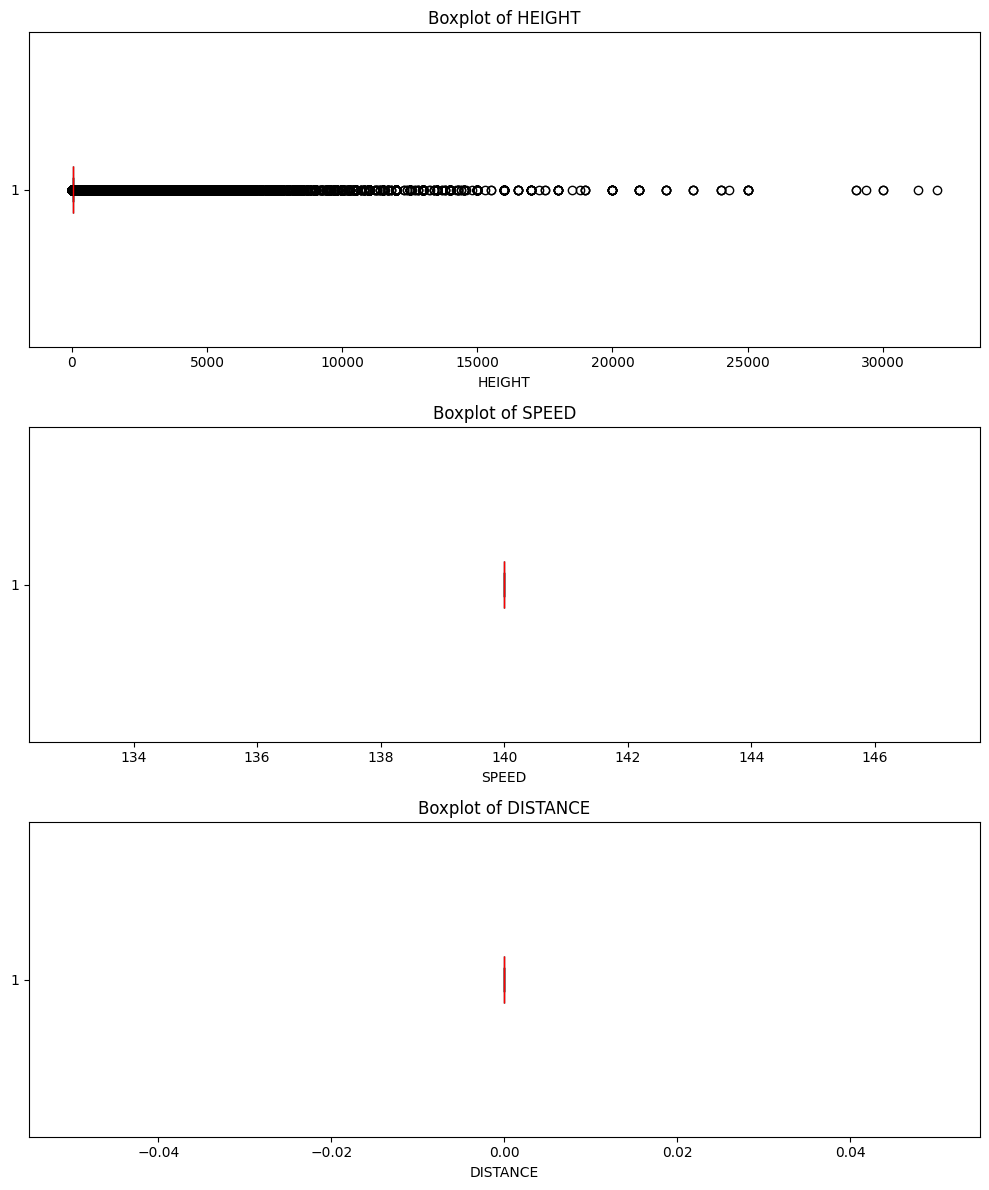

In [6]:

# Visualize boxplots for key numeric fields
plot_cols = [c for c in ['HEIGHT', 'SPEED', 'DISTANCE'] if c in train_clean.columns]
if plot_cols:
    fig, axes = plt.subplots(len(plot_cols), 1, figsize=(10, 4 * len(plot_cols)))
    if len(plot_cols) == 1:
        axes = [axes]
    for ax, col in zip(axes, plot_cols):
        ax.boxplot(train_clean[col].dropna(), vert=False, patch_artist=True,
                   boxprops=dict(facecolor='lightblue', color='black'),
                   medianprops=dict(color='red'))
        ax.set_title(f'Boxplot of {col}')
        ax.set_xlabel(col)
    plt.tight_layout()
    plt.show()


### Capping Numeric Features
This led us to the conclusion that we needed to cap numeric features using the IQR method we learned about. We first decided to do some median imputation; height based on phase seemed like a very solid approximation and not one that would skew the data too much - phase is generally a solid tell for the height, logically looking at the different categories. We also created mappings for features that were redundant here.

In [ ]:
#impute height using median per phase of flight
phase_median = train_clean.groupby('PHASE_OF_FLIGHT')['HEIGHT'].median()
train_clean['HEIGHT'] = train_clean.apply(
    lambda row: phase_median[row['PHASE_OF_FLIGHT']] if pd.isna(row['HEIGHT']) else row['HEIGHT'],
    axis=1
)
# For test, use same phase_median dict (fill any missing phase with overall median)

#create mapping from opid to operator
opid_to_operator = train_clean.groupby('OPID')['OPERATOR'].agg(lambda x: x.mode()[0] if not x.mode().empty else 'Unknown')
train_clean['OPERATOR'] = train_clean.apply(
    lambda row: opid_to_operator[row['OPID']] if pd.isna(row['OPERATOR']) else row['OPERATOR'],
    axis=1
)

#do the same for aircrafts to engines, which are also one to one
aircraft_to_eng = train_clean.groupby('AIRCRAFT')['TYPE_ENG'].agg(lambda x: x.mode()[0] if not x.mode().empty else 'Unknown')
train_clean['TYPE_ENG'] = train_clean.apply(
    lambda row: aircraft_to_eng[row['AIRCRAFT']] if pd.isna(row['TYPE_ENG']) else row['TYPE_ENG'],
    axis=1
)

def cap_outliers_iqr(df, columns, multiplier=3.0):
    df_capped = df.copy()
    
    for col in columns:
        if col not in df.columns:
            continue
            
        #get quantities
        Q1 = df[col].quantile(0.25)
        Q3 = df[col].quantile(0.75)
        IQR = Q3 - Q1
        
        #define bounds
        lower_bound = Q1 - multiplier * IQR
        upper_bound = Q3 + multiplier * IQR
        
        #count outliers before capping
        outliers_before = ((df[col] < lower_bound) | (df[col] > upper_bound)).sum()
        
        #cap the values
        df_capped[col] = df_capped[col].clip(lower=lower_bound, upper=upper_bound)
        
        if outliers_before > 0:
            print(f"  {col}: Capped {outliers_before} outliers using IQR={IQR:.2f}, bounds=({lower_bound:.2f}, {upper_bound:.2f})")
    
    return df_capped

#columns that needed outlier capping based on our detection output
outlier_columns = [
    'SPEED', 'DISTANCE',
    'AMA', 'AMO', 'EMA', 'EMO', 'AC_MASS', 'NUM_ENGS',
    'ENG_1_POS', 'ENG_2_POS', 'ENG_3_POS', 'ENG_4_POS',
    'NUM_SEEN', 'NUM_STRUCK'
]

print("\n" + "="*60)
print("APPLYING OUTLIER CAPPING (3.0 * IQR) - MORE CONSERVATIVE APPROACH")
print("="*60)

#apply to both
train_clean = cap_outliers_iqr(train_clean, outlier_columns, multiplier=3.0)
test_clean = cap_outliers_iqr(test_clean, outlier_columns, multiplier=3.0)


APPLYING OUTLIER CAPPING (3.0 * IQR) - CONSERVATIVE APPROACH
  SPEED: Capped 84952 outliers using IQR=0.00, bounds=(140.00, 140.00)
  DISTANCE: Capped 26123 outliers using IQR=0.00, bounds=(0.00, 0.00)
  AMA: Capped 52124 outliers using IQR=40.00, bounds=(28.00, 308.00)
  AMO: Capped 8800 outliers using IQR=11.00, bounds=(-20.00, 57.00)
  EMO: Capped 27602 outliers using IQR=3.00, bounds=(-8.00, 13.00)
  AC_MASS: Capped 62475 outliers using IQR=0.00, bounds=(4.00, 4.00)
  NUM_ENGS: Capped 27031 outliers using IQR=0.00, bounds=(2.00, 2.00)
  ENG_3_POS: Capped 6143 outliers using IQR=0.00, bounds=(1.00, 1.00)
  ENG_4_POS: Capped 1264 outliers using IQR=0.00, bounds=(1.00, 1.00)
  SPEED: Capped 9479 outliers using IQR=0.00, bounds=(140.00, 140.00)
  DISTANCE: Capped 2837 outliers using IQR=0.00, bounds=(0.00, 0.00)
  AMA: Capped 5906 outliers using IQR=40.00, bounds=(28.00, 308.00)
  AMO: Capped 973 outliers using IQR=11.00, bounds=(-20.00, 57.00)
  EMO: Capped 3071 outliers using IQR=3.

### Beginning More Explicit Data Exploration
We thought this was a good point now from which to look at our data again, and we looked at features we thought would be fruitful for further analysis.

In [4]:
# Basic dataset overview
print('Train shape:', train_clean.shape)
print('\nTarget distribution:')
print(train_clean['INDICATED_DAMAGE'].value_counts(normalize=True).rename('proportion'))

# Numeric overview
numeric_cols = train_clean.select_dtypes(include=['float64', 'int64']).columns.tolist()
print('\nNumeric summary:')
print(train_clean[numeric_cols].describe().T[['mean', 'std', 'min', '25%', '50%', '75%', 'max']])

# Top categorical levels and target relationships

#We decided these had the most importance
cat_cols = ['TIME_OF_DAY', 'PHASE_OF_FLIGHT', 'SIZE', 'SKY', 'PRECIPITATION', 'SPECIES', 'AIRCRAFT']
for col in cat_cols:
    if col in train_clean.columns:
        print(f'\nTop values for {col}:')
        print(train_clean[col].value_counts(dropna=False).head(10))
        print(f'\nINDICATED_DAMAGE rate by {col}:')
        print(train_clean.groupby(col)['INDICATED_DAMAGE'].mean().sort_values(ascending=False).head(10))

# Cross-tab examples for feature selection
if 'PHASE_OF_FLIGHT' in train_clean.columns and 'SIZE' in train_clean.columns:
    print('\nDamage rate by phase of flight and size:')
    print(train_clean.pivot_table(index='PHASE_OF_FLIGHT', columns='SIZE', values='INDICATED_DAMAGE', aggfunc='mean').round(3))

if 'TIME_OF_DAY' in train_clean.columns:
    print('\nDamage rate by time of day:')
    print(train_clean.groupby('TIME_OF_DAY')['INDICATED_DAMAGE'].mean().round(3))

Train shape: (307178, 70)

Target distribution:
INDICATED_DAMAGE
0    0.936431
1    0.063569
Name: proportion, dtype: Float64

Numeric summary:
                           mean          std        min        25%       50%  \
INCIDENT_MONTH         7.221136     2.750603        1.0        5.0       8.0   
INCIDENT_YEAR       2013.629697     8.991125     1990.0     2008.0    2015.0   
LATITUDE              37.036431     6.344318 -37.673333   33.64044  38.69542   
LONGITUDE            -91.139904    22.706519   -177.381 -97.308078 -87.90446   
AMA                  221.879047    141.96458        4.0      148.0     168.0   
AMO                   21.455951    17.361811        0.0       13.0      17.0   
EMA                   20.206125     8.725608        1.0       10.0      22.0   
EMO                    6.626598     9.356931        0.0        1.0       4.0   
AC_MASS                3.683662     0.758936        1.0        4.0       4.0   
NUM_ENGS               2.003093     0.346287        1.0 

### Visual Data Exploration

This section creates visual charts for the cleaned dataset. It visualizes the target distribution, major categorical relationships, missingness, numeric feature distributions, and species-level patterns.

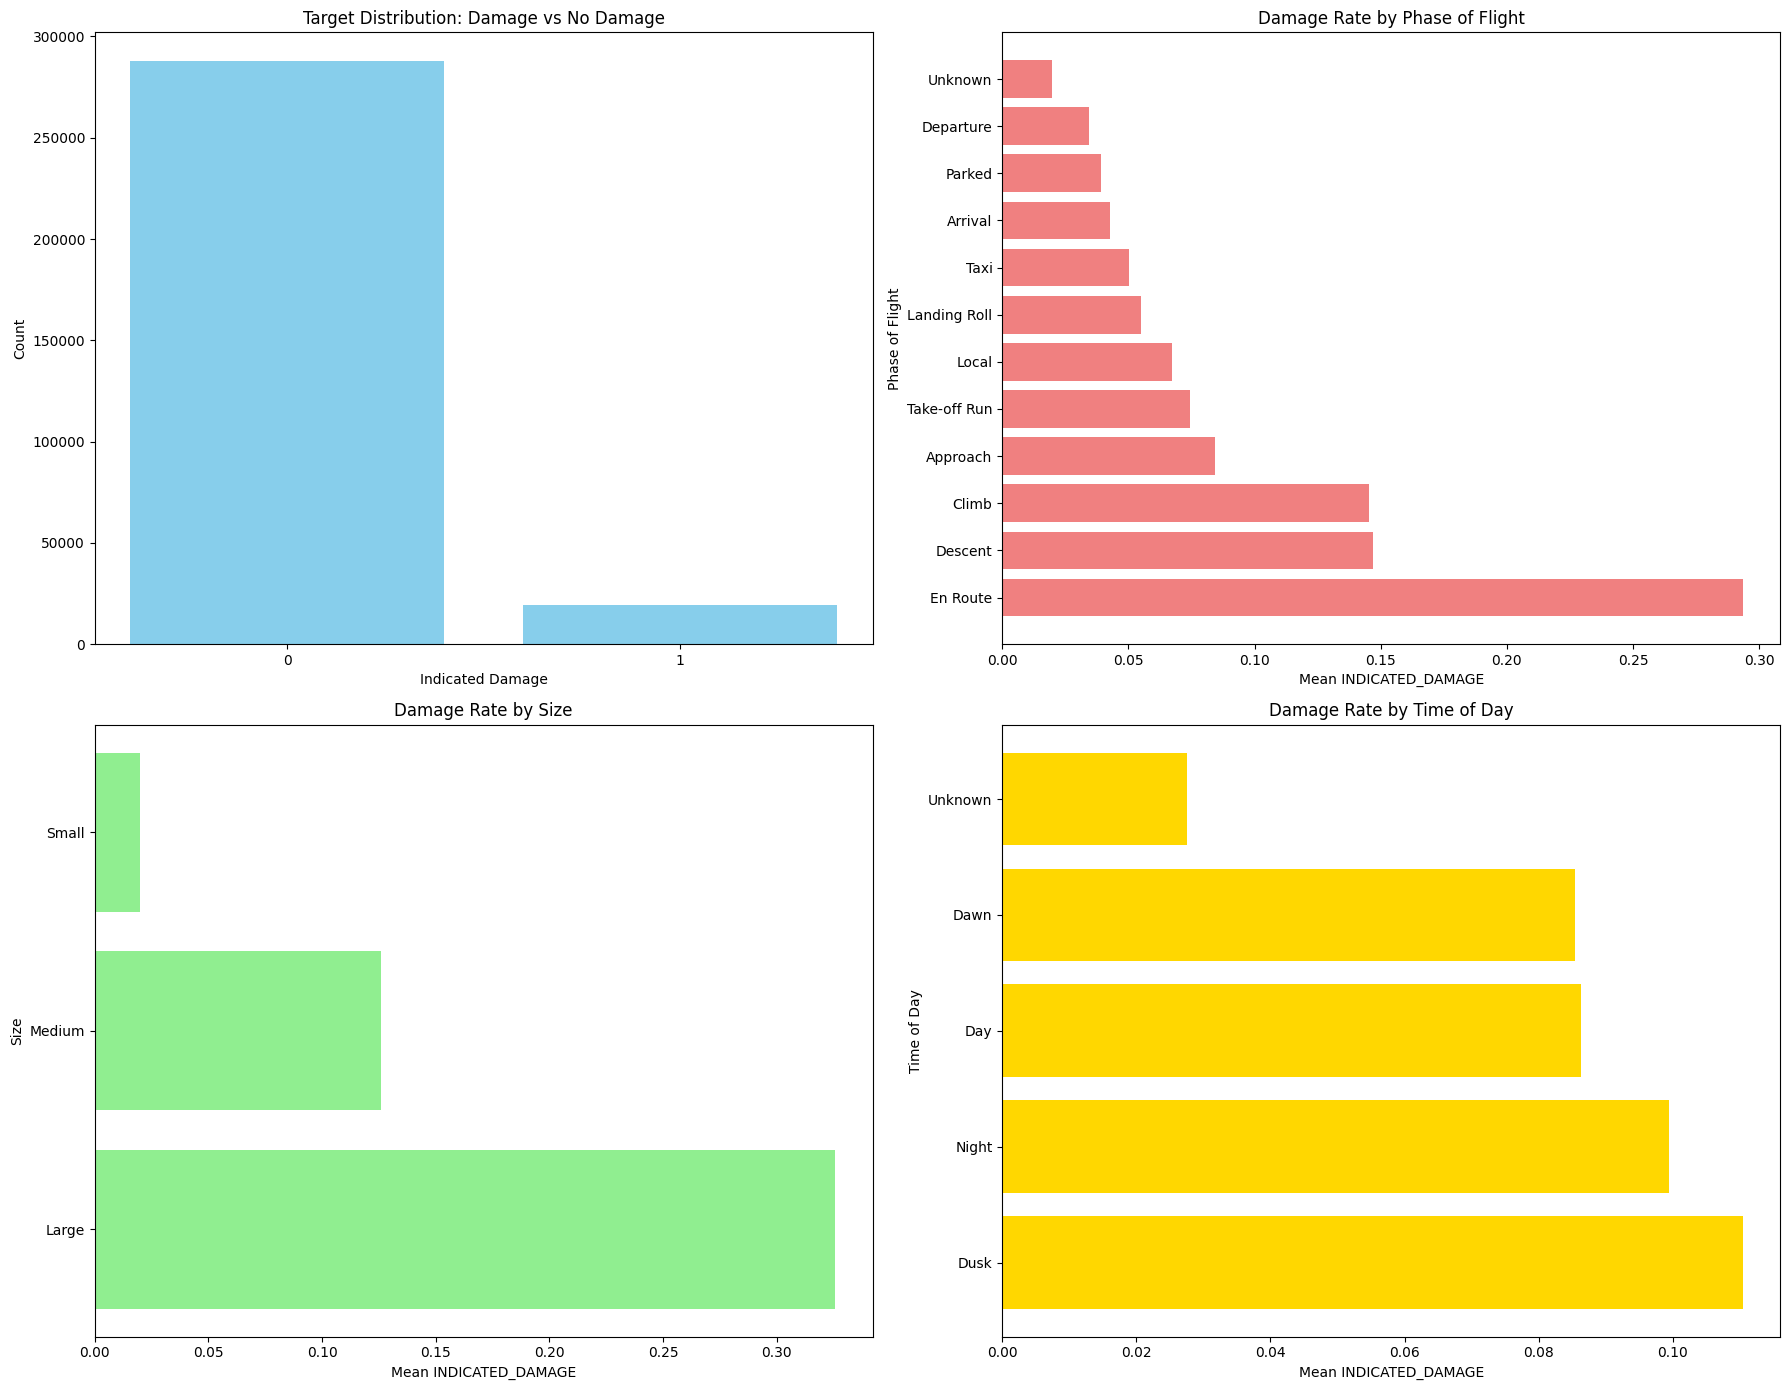

In [8]:
import matplotlib.pyplot as plt

plt.style.use('seaborn-v0_8-muted')
plt.rcParams['figure.figsize'] = (14, 7)

# Target distribution and categorical damage-rate visuals
fig, axes = plt.subplots(2, 2, figsize=(18, 14))

# Target distribution
damage_counts = train_clean['INDICATED_DAMAGE'].value_counts()
axes[0, 0].bar(damage_counts.index.astype(str), damage_counts.values, color='skyblue')
axes[0, 0].set_title('Target Distribution: Damage vs No Damage')
axes[0, 0].set_xlabel('Indicated Damage')
axes[0, 0].set_ylabel('Count')

# Phase of flight damage rate
if 'PHASE_OF_FLIGHT' in train_clean.columns:
    phase_rate = train_clean.groupby('PHASE_OF_FLIGHT')['INDICATED_DAMAGE'].mean().sort_values(ascending=False)
    axes[0, 1].barh(phase_rate.index, phase_rate.values, color='lightcoral')
    axes[0, 1].set_title('Damage Rate by Phase of Flight')
    axes[0, 1].set_xlabel('Mean INDICATED_DAMAGE')
    axes[0, 1].set_ylabel('Phase of Flight')

# Size damage rate
if 'SIZE' in train_clean.columns:
    size_rate = train_clean.groupby('SIZE')['INDICATED_DAMAGE'].mean().sort_values(ascending=False)
    axes[1, 0].barh(size_rate.index, size_rate.values, color='lightgreen')
    axes[1, 0].set_title('Damage Rate by Size')
    axes[1, 0].set_xlabel('Mean INDICATED_DAMAGE')
    axes[1, 0].set_ylabel('Size')

# Time of day damage rate
if 'TIME_OF_DAY' in train_clean.columns:
    time_rate = train_clean.groupby('TIME_OF_DAY')['INDICATED_DAMAGE'].mean().sort_values(ascending=False)
    axes[1, 1].barh(time_rate.index, time_rate.values, color='gold')
    axes[1, 1].set_title('Damage Rate by Time of Day')
    axes[1, 1].set_xlabel('Mean INDICATED_DAMAGE')
    axes[1, 1].set_ylabel('Time of Day')

plt.tight_layout()
plt.show()

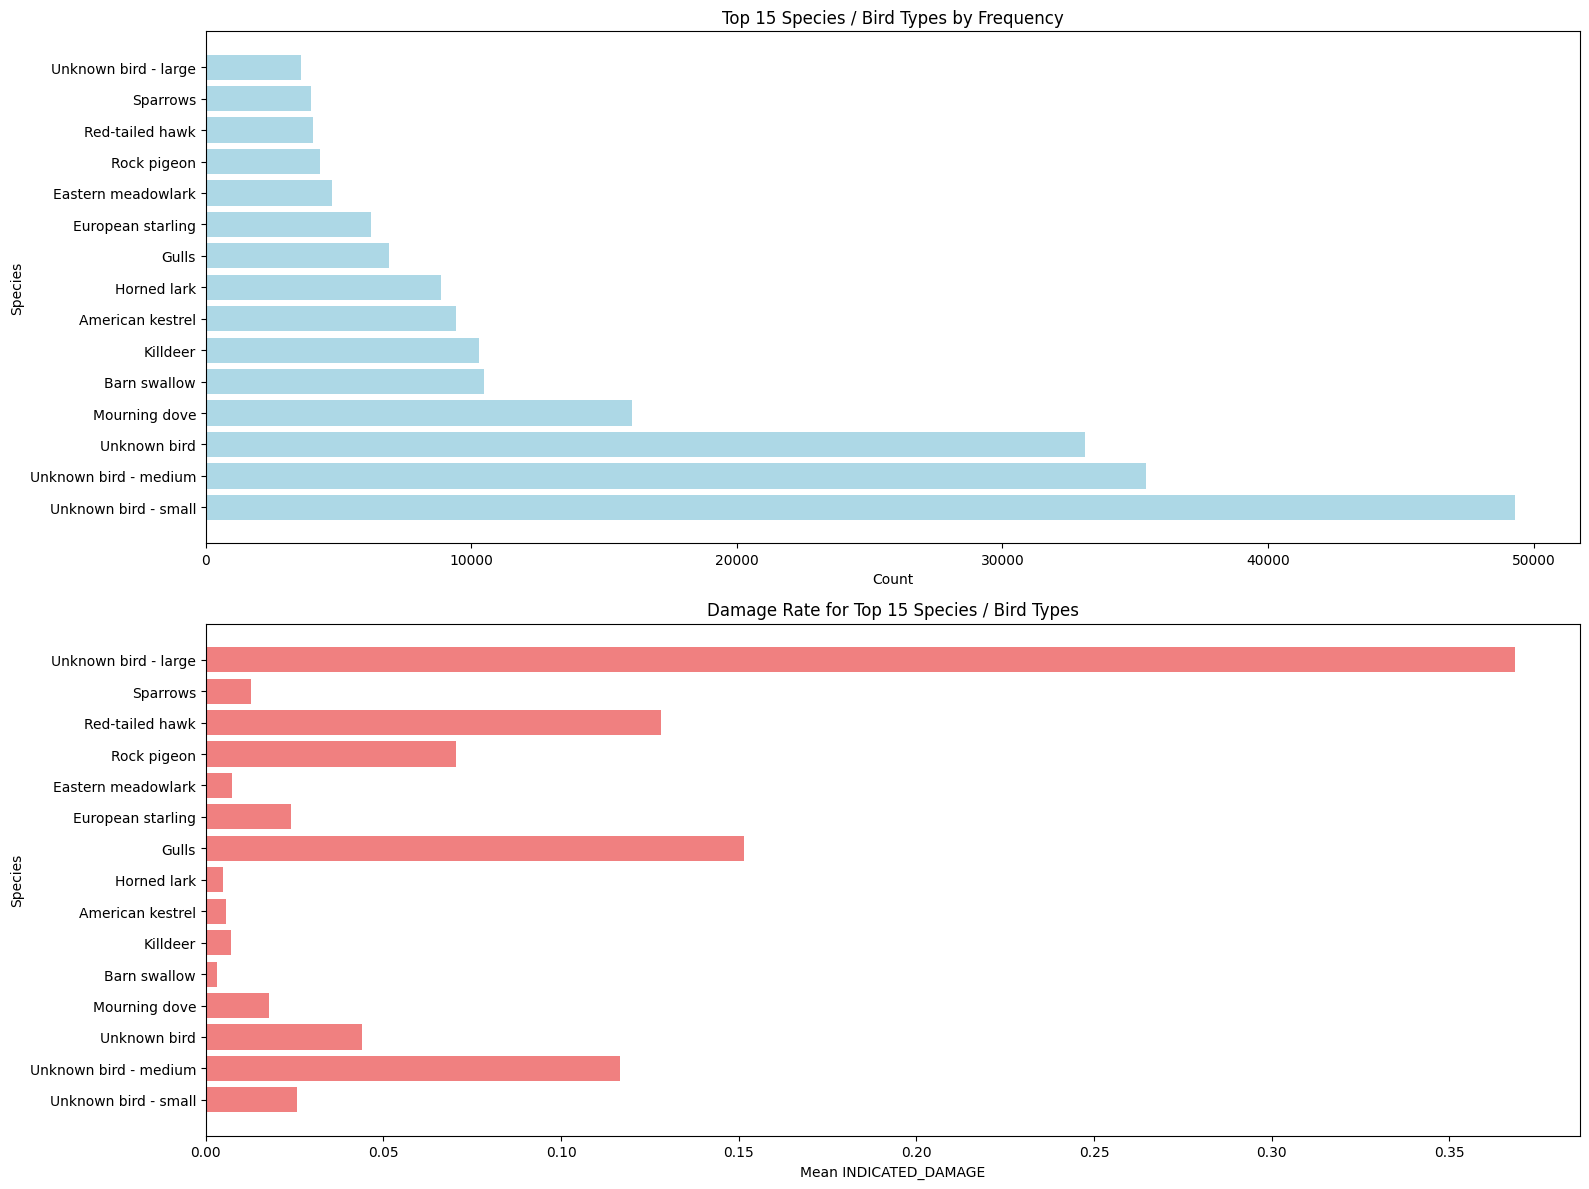

In [14]:
# Species frequency and damage rate visualization
if 'SPECIES' in train_clean.columns:
    top_species = train_clean['SPECIES'].value_counts().head(15).index
    species_counts = train_clean['SPECIES'].value_counts().loc[top_species]
    species_rates = train_clean.groupby('SPECIES')['INDICATED_DAMAGE'].mean().loc[top_species]
    fig, axes = plt.subplots(2, 1, figsize=(16, 12))
    axes[0].barh(species_counts.index, species_counts.values, color='lightblue')
    axes[0].set_title('Top 15 Species / Bird Types by Frequency')
    axes[0].set_xlabel('Count')
    axes[0].set_ylabel('Species')

    axes[1].barh(species_rates.index, species_rates.values, color='lightcoral')
    axes[1].set_title('Damage Rate for Top 15 Species / Bird Types')
    axes[1].set_xlabel('Mean INDICATED_DAMAGE')
    axes[1].set_ylabel('Species')
    plt.tight_layout()
    plt.show()


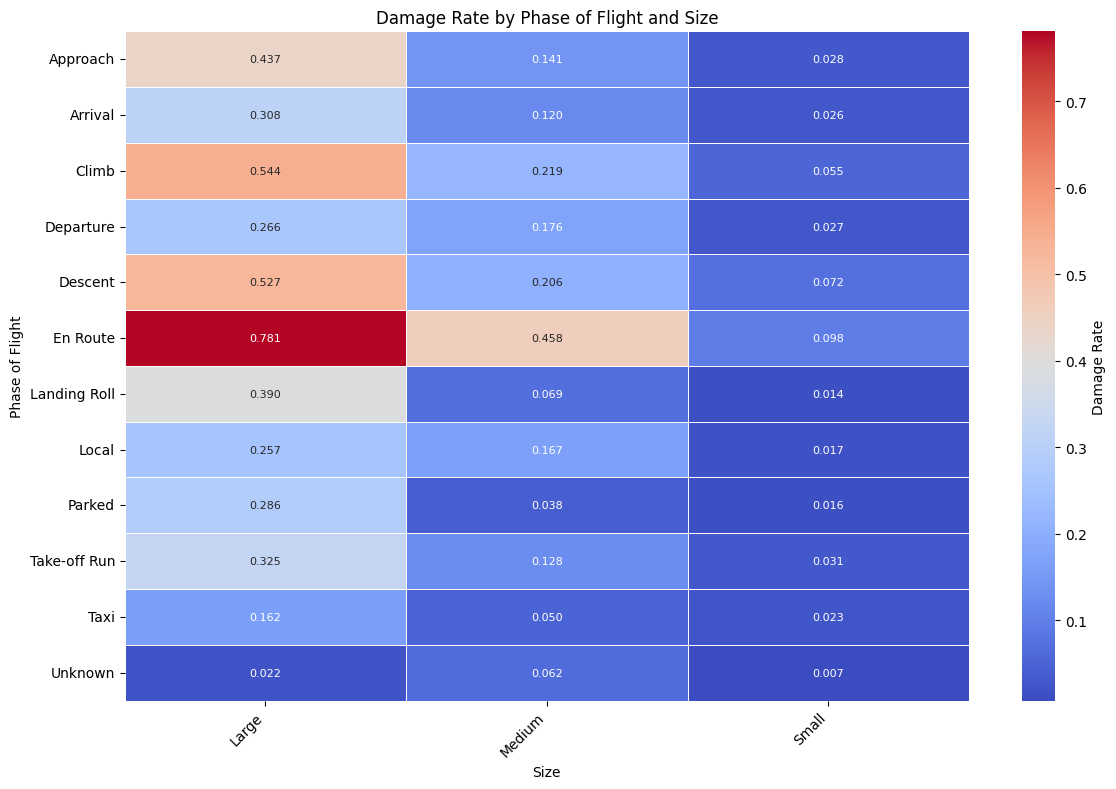

In [15]:
# Heatmap of damage rate by phase of flight and size
if {'PHASE_OF_FLIGHT', 'SIZE'}.issubset(train_clean.columns):
    import seaborn as sns

    pivot = train_clean.pivot_table(index='PHASE_OF_FLIGHT', columns='SIZE', values='INDICATED_DAMAGE', aggfunc='mean')
    pivot = pivot.apply(pd.to_numeric, errors='coerce')
    pivot_data = pivot.values.astype(float)
    fig_width = max(12, len(pivot.columns) * 0.8)
    fig_height = max(8, len(pivot.index) * 0.6)

    plt.figure(figsize=(fig_width, fig_height))
    sns.heatmap(
        pivot_data,
        mask=np.isnan(pivot_data),
        annot=True,
        fmt='.3f',
        cmap='coolwarm',
        linewidths=0.5,
        cbar_kws={'label': 'Damage Rate'},
        annot_kws={'size': 8},
        square=False,
        linecolor='white',
        xticklabels=pivot.columns,
        yticklabels=pivot.index
    )
    plt.xticks(rotation=45, ha='right')
    plt.yticks(rotation=0)
    plt.title('Damage Rate by Phase of Flight and Size')
    plt.xlabel('Size')
    plt.ylabel('Phase of Flight')
    plt.tight_layout()
    plt.show()


# Feature Relationships and Engineering Insights
This next subsection explores relationships between features to guide our feature engineering. We'll look at correlations between numeric features, associations between categorical features, and relationships with the target to identify redundant or predictive variables. As we engineer some features, we also "clean" out others - we were getting a feel for the process and just documented it sequentially here.

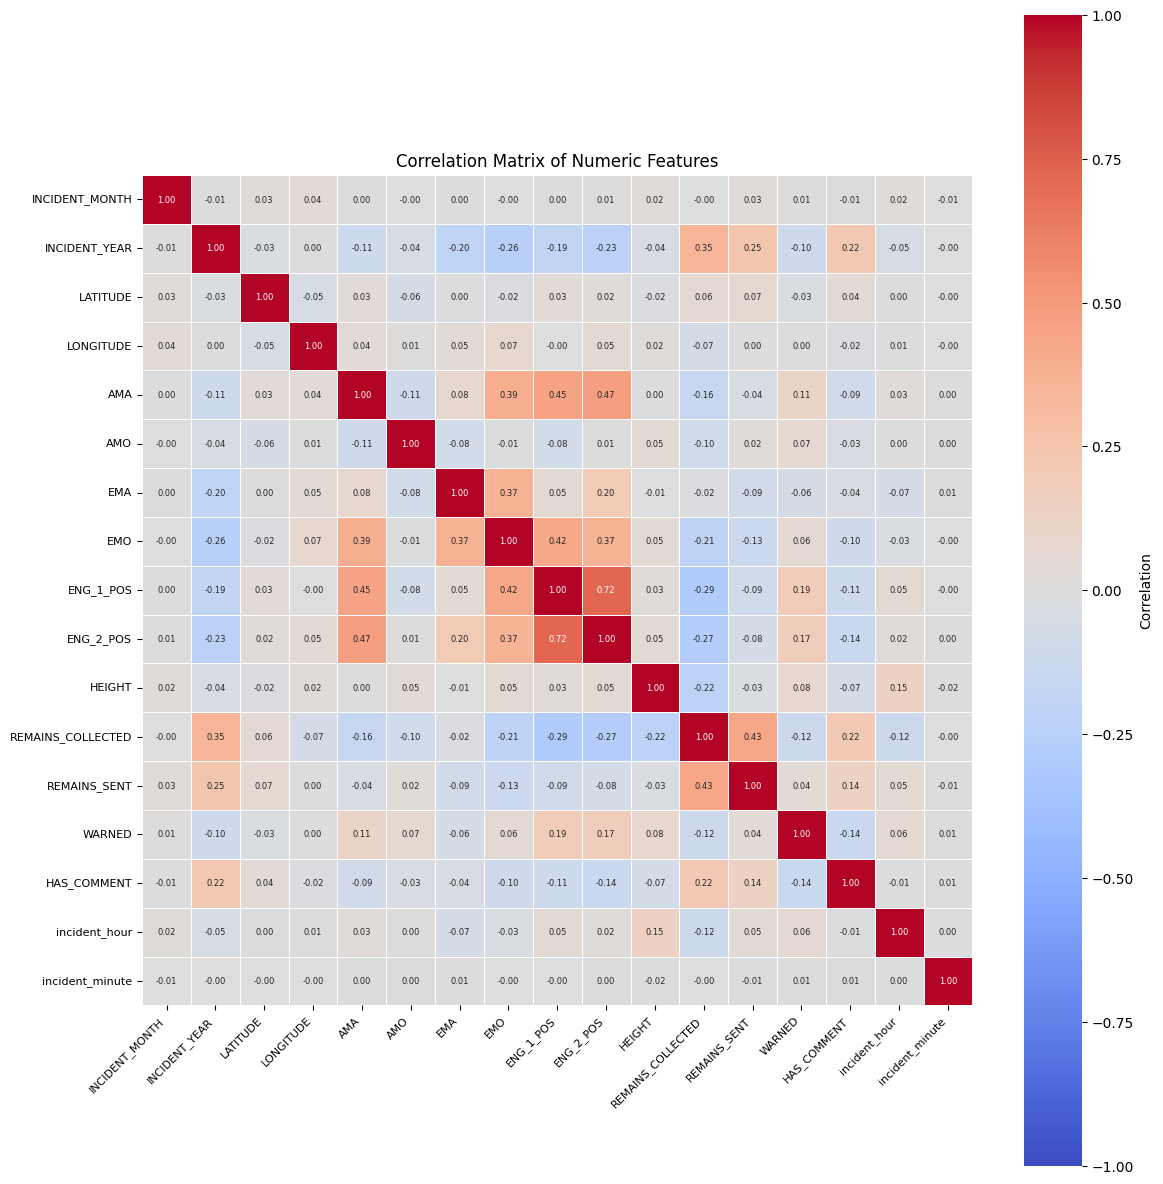

Highly correlated feature pairs (|corr| > 0.7):
      Feature1   Feature2  Correlation
100  ENG_1_POS  ENG_2_POS     0.722523


In [16]:
# Correlation matrix for numeric features
numeric_cols = train_clean.select_dtypes(include=['float64', 'int64']).columns.tolist()
numeric_cols = [c for c in numeric_cols if c != 'INDICATED_DAMAGE']  # Exclude target for now
numeric_cols = [c for c in numeric_cols if not c.endswith("_missing")]  # Exclude missing indicators
numeric_cols = [c for c in numeric_cols if train_clean[c].var() > 0]  # Exclude constant features

if numeric_cols:
    import seaborn as sns

    corr_matrix = train_clean[numeric_cols].corr()
    fig_size = max(12, len(corr_matrix.columns) * 0.5)
    fig, ax = plt.subplots(figsize=(fig_size, fig_size))
    sns.heatmap(
        corr_matrix,
        annot=True,
        fmt='.2f',
        cmap='coolwarm',
        linewidths=0.4,
        cbar_kws={'label': 'Correlation'},
        annot_kws={'size': 6},
        square=True,
        ax=ax,
        vmin=-1,
        vmax=1
    )
    ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha='right', fontsize=8)
    ax.set_yticklabels(ax.get_yticklabels(), rotation=0, fontsize=8)
    ax.set_title('Correlation Matrix of Numeric Features')
    plt.tight_layout()
    plt.show()

    # Print high correlations (>0.7 or <-0.7)
    high_corr = corr_matrix.where(np.triu(np.ones_like(corr_matrix), k=1).astype(bool))
    high_corr_pairs = high_corr.stack().reset_index()
    high_corr_pairs.columns = ['Feature1', 'Feature2', 'Correlation']
    high_corr_pairs = high_corr_pairs[high_corr_pairs['Correlation'].abs() > 0.7]
    if not high_corr_pairs.empty:
        print('Highly correlated feature pairs (|corr| > 0.7):')
        print(high_corr_pairs.sort_values('Correlation', ascending=False))
    else:
        print('No highly correlated numeric feature pairs found.')


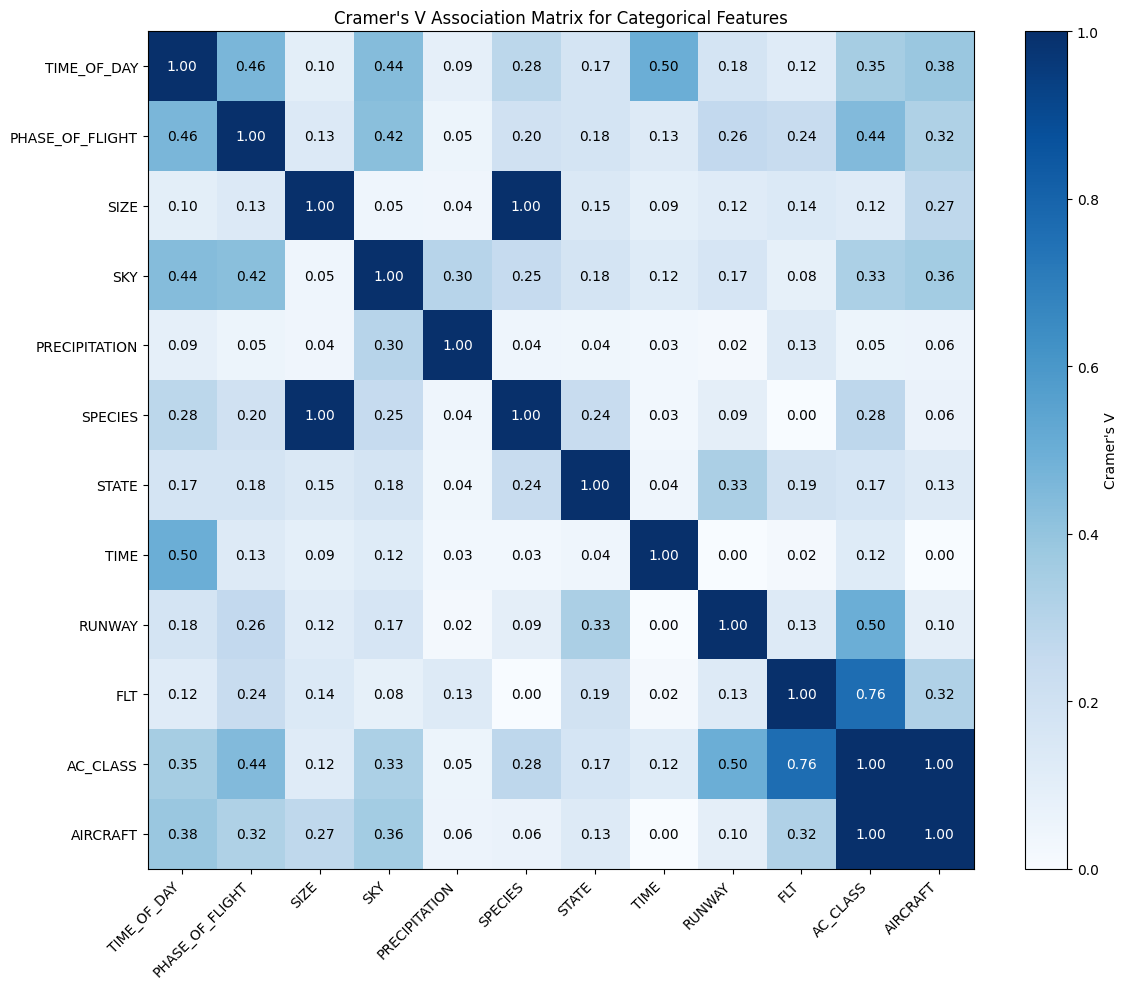

Strongly associated categorical feature pairs (Cramers V > 0.5):
    Feature1  Feature2 Cramers_V
65  AC_CLASS  AIRCRAFT  0.998999
23      SIZE   SPECIES  0.998307
63       FLT  AC_CLASS  0.762853


In [ ]:
# Cramer's V for categorical feature associations - good way to check overlap
import scipy.stats as stats
import numpy as np

def cramers_v(confusion_matrix):
    chi2 = stats.chi2_contingency(confusion_matrix)[0]
    n = confusion_matrix.sum().sum()
    phi2 = chi2 / n
    r, k = confusion_matrix.shape
    phi2corr = max(0, phi2 - ((k-1)*(r-1))/(n-1))
    rcorr = r - ((r-1)**2)/(n-1)
    kcorr = k - ((k-1)**2)/(n-1)
    return np.sqrt(phi2corr / min((kcorr-1), (rcorr-1)))

cat_cols = ['TIME_OF_DAY', 'PHASE_OF_FLIGHT', 'SIZE', 'SKY', 'PRECIPITATION', 'SPECIES', 'FAAREGION', 'STATE', 'TIME', 'RUNWAY', 'FLT', 'AC_CLASS', 'AIRCRAFT']
cat_cols = [c for c in cat_cols if c in train_clean.columns]

if len(cat_cols) > 1:
    cramers_matrix = pd.DataFrame(index=cat_cols, columns=cat_cols)
    for i in range(len(cat_cols)):
        for j in range(len(cat_cols)):
            if i == j:
                cramers_matrix.iloc[i, j] = 1.0
            else:
                contingency = pd.crosstab(train_clean[cat_cols[i]], train_clean[cat_cols[j]])
                cramers_matrix.iloc[i, j] = cramers_v(contingency.values)
    
    plt.figure(figsize=(12, 10))
    im = plt.imshow(cramers_matrix.values.astype(float), cmap='Blues', aspect='auto', vmin=0, vmax=1)
    plt.colorbar(im, label="Cramer's V")
    plt.xticks(range(len(cat_cols)), cat_cols, rotation=45, ha='right')
    plt.yticks(range(len(cat_cols)), cat_cols)
    plt.title("Cramer's V Association Matrix for Categorical Features")
    for i in range(len(cat_cols)):
        for j in range(len(cat_cols)):
            text = plt.text(j, i, f'{cramers_matrix.values[i, j]:.2f}', ha='center', va='center', color='white' if cramers_matrix.values[i, j] > 0.5 else 'black')
    plt.tight_layout()
    plt.show()

    # Print strong associations (>0.5)
    strong_assoc = cramers_matrix.where(np.triu(np.ones_like(cramers_matrix), k=1).astype(bool))
    strong_pairs = strong_assoc.stack().reset_index()
    strong_pairs.columns = ['Feature1', 'Feature2', 'Cramers_V']
    strong_pairs = strong_pairs[strong_pairs['Cramers_V'] > 0.5]
    if not strong_pairs.empty:
        print('Strongly associated categorical feature pairs (Cramers V > 0.5):')
        print(strong_pairs.sort_values('Cramers_V', ascending=False))
    else:
        print('No strongly associated categorical feature pairs found.')


Point-biserial correlations with INDICATED_DAMAGE:
ENG_1_POS: correlation=0.1771, p-value=0.0
INCIDENT_YEAR: correlation=-0.1386, p-value=0.0
REMAINS_COLLECTED: correlation=-0.1184, p-value=0.0
HEIGHT: correlation=0.1110, p-value=0.0
EMO: correlation=0.0934, p-value=0.0
ENG_2_POS: correlation=0.0707, p-value=0.0
AMA: correlation=0.0706, p-value=0.0
WARNED: correlation=0.0656, p-value=5.314785197128133e-290
incident_hour: correlation=0.0445, p-value=1.7993663994631554e-77
TIME: correlation=0.0356, p-value=1.3057280034303533e-86
HAS_COMMENT: correlation=0.0274, p-value=5.075866352434162e-52
REMAINS_SENT: correlation=0.0212, p-value=6.285104447050533e-32
LATITUDE: correlation=0.0189, p-value=8.461912991598064e-26
EMA: correlation=-0.0147, p-value=3.87137865080892e-16
INCIDENT_MONTH: correlation=-0.0147, p-value=4.555305365851605e-16
incident_minute: correlation=-0.0097, p-value=5.028746893847697e-05
LONGITUDE: correlation=0.0075, p-value=2.9953580219740305e-05
AMO: correlation=-0.0029, p-

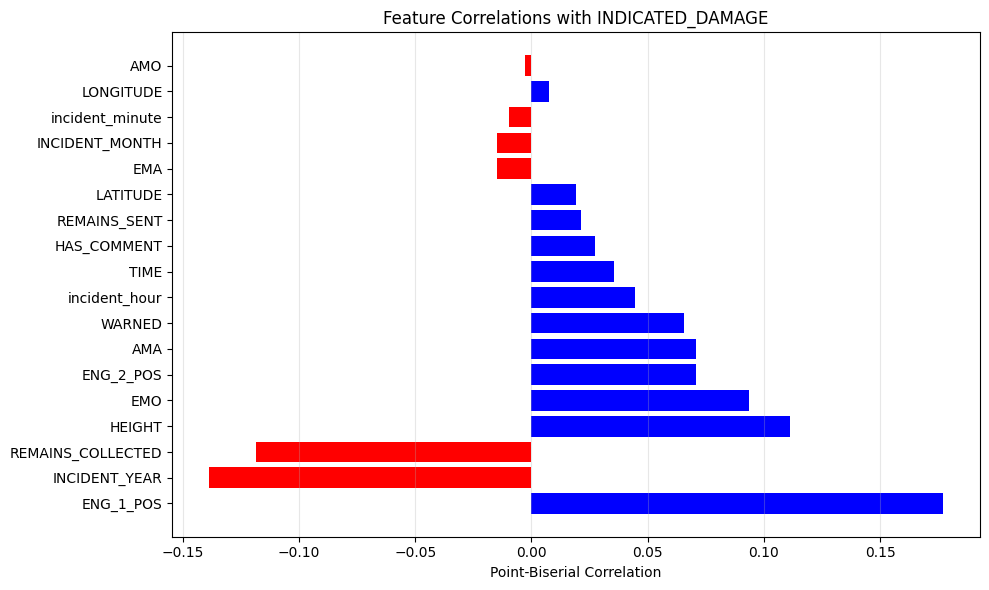

In [ ]:
#point-biserial correlation with target
from scipy.stats import pointbiserialr

if 'INDICATED_DAMAGE' in train_clean.columns:
    target = train_clean["INDICATED_DAMAGE"].astype(int)
    correlations_with_target = {}
    
    def safe_pointbiserial(x, y):
        combined = pd.concat([x, y], axis=1).dropna()
        if combined.empty or combined.iloc[:, 0].nunique() <= 1 or combined.iloc[:, 1].nunique() <= 1:
            return np.nan, np.nan
        return pointbiserialr(combined.iloc[:, 0], combined.iloc[:, 1])
    
    #numeric features
    for col in numeric_cols:
        if col in train_clean.columns:
            corr, p = safe_pointbiserial(target, train_clean[col])
            correlations_with_target[col] = {"correlation": corr, "p_value": p}
    
    #binary/categorical features (encode as numeric)
    binary_cols = ["REMAINS_COLLECTED", "REMAINS_SENT", "WARNED"]
    for col in binary_cols:
        if col in train_clean.columns:
            encoded = train_clean[col].astype(int)
            corr, p = safe_pointbiserial(target, encoded)
            correlations_with_target[col] = {"correlation": corr, "p_value": p}
    
    #encode TIME as numeric (minutes past midnight)
    if 'TIME' in train_clean.columns:
        time_numeric = pd.to_datetime(train_clean['TIME'], format='%H:%M', errors='coerce').dt.hour * 60 + pd.to_datetime(train_clean['TIME'], format='%H:%M', errors='coerce').dt.minute
        time_numeric = time_numeric.fillna(time_numeric.median())
        corr, p = safe_pointbiserial(target, time_numeric)
        correlations_with_target['TIME'] = {"correlation": corr, "p_value": p}
    
    #exclude _missing indicator features from correlations
    correlations_with_target = {k: v for k, v in correlations_with_target.items() if not k.endswith("_missing")}
    
    #display the correlations sorted by absolute strength
    corr_summary = sorted(
        correlations_with_target.items(),
        key=lambda item: abs(item[1]["correlation"]) if not np.isnan(item[1]["correlation"]) else -1,
        reverse=True
    )
    print("Point-biserial correlations with INDICATED_DAMAGE:")
    for col, stats in corr_summary:
        if np.isnan(stats["correlation"]):
            print(f"{col}: correlation=nan, p-value=nan")
        else:
            print(f"{col}: correlation={stats["correlation"]:.4f}, p-value={stats["p_value"]}")
    
    # Visualize the correlations
    import matplotlib.pyplot as plt
    valid_corrs = [(col, stats["correlation"]) for col, stats in corr_summary if not np.isnan(stats["correlation"])]
    if valid_corrs:
        cols, corrs = zip(*valid_corrs)
        plt.figure(figsize=(10, max(6, len(cols) * 0.3)))
        bars = plt.barh(cols, corrs, color=["red" if c < 0 else "blue" for c in corrs])
        plt.xlabel("Point-Biserial Correlation")
        plt.title("Feature Correlations with INDICATED_DAMAGE")
        plt.grid(axis="x", alpha=0.3)
        plt.tight_layout()
        plt.show()


In [ ]:
#confirmation that our cleaning has been successful:
#re-run data cleaning and ensure SIZE and FAAREGION are removed from the cleaned dataset


#removing size and farregion bc theyre repetitive, removing time bc data shown through time of day feature already
train_clean = clean_wildlife_strike_df(train, is_train=True)
test_clean = clean_wildlife_strike_df(test, is_train=False)

for df_label, df in [('train_clean', train_clean), ('test_clean', test_clean)]:
    for drop_col in ['SIZE', 'FAAREGION']:
        if drop_col in df.columns:
            df = df.drop(columns=[drop_col])
    if df_label == 'train_clean':
        train_clean = df
    else:
        test_clean = df

print('Cleaned train shape:', train_clean.shape)
print('Removed columns from train_clean:', [c for c in ['SIZE', 'FAAREGION', 'TIME'] if c not in train_clean.columns])
print('Sample cleaned columns:')
print(train_clean.columns.tolist())


C:\Users\sebia\AppData\Local\Temp\ipykernel_29068\3801652953.py:9: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  df['INCIDENT_DATE'] = pd.to_datetime(df['INCIDENT_DATE'], errors='coerce')


Train - HAS_COMMENT: 271871 rows (88.51%)


C:\Users\sebia\AppData\Local\Temp\ipykernel_29068\3801652953.py:9: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  df['INCIDENT_DATE'] = pd.to_datetime(df['INCIDENT_DATE'], errors='coerce')


Test - HAS_COMMENT: 30276 rows (88.71%)
Cleaned train shape: (307178, 69)
Removed columns from train_clean: ['SIZE', 'FAAREGION']
Sample cleaned columns:
['INCIDENT_MONTH', 'INCIDENT_YEAR', 'TIME', 'TIME_OF_DAY', 'AIRPORT_ID', 'LATITUDE', 'LONGITUDE', 'RUNWAY', 'STATE', 'OPID', 'OPERATOR', 'REG', 'FLT', 'AIRCRAFT', 'AMA', 'AMO', 'EMA', 'EMO', 'AC_CLASS', 'AC_MASS', 'TYPE_ENG', 'NUM_ENGS', 'ENG_1_POS', 'ENG_2_POS', 'ENG_3_POS', 'ENG_4_POS', 'PHASE_OF_FLIGHT', 'HEIGHT', 'SPEED', 'DISTANCE', 'SKY', 'PRECIPITATION', 'BIRD_BAND_NUMBER', 'SPECIES_ID', 'SPECIES', 'OUT_OF_RANGE_SPECIES', 'REMAINS_COLLECTED', 'REMAINS_SENT', 'WARNED', 'NUM_SEEN', 'NUM_STRUCK', 'ENROUTE_STATE', 'SOURCE', 'PERSON', 'INDICATED_DAMAGE', 'incident_year', 'incident_month', 'incident_day', 'incident_weekday', 'HAS_COMMENT', 'incident_hour', 'incident_minute', 'LATITUDE_missing', 'LONGITUDE_missing', 'AMA_missing', 'AMO_missing', 'EMA_missing', 'EMO_missing', 'AC_MASS_missing', 'NUM_ENGS_missing', 'ENG_1_POS_missing', 

# Feature Engineering/Cleaning Insights

Based on the relationship analysis, we found this:

Features with missing info:
FLT                     52.554219 doesn't really give important information.

TIME                    42.985500 keep -> convert to minutes past midnight so its not categorical

incident_minute         42.985500  we can use time to show that data

incident_hour           42.985500 we can use time to show that data

RUNWAY                  24.606254  is blank if airborne, so not a case of missing data 

ICAO make model describes for the most part the aircraft model except for minor differences, remove aircraft feature, aircraft also maches w ac class

remove remains collected - we decided that this felt like leakage after all

In [20]:
# Remove features FLT, incident_minute, incident_hour
# Convert TIME to minutes past midnight
if 'FLT' in train_clean.columns:
    train_clean = train_clean.drop(columns=['FLT'])
    test_clean = test_clean.drop(columns=['FLT'])
if 'incident_minute' in train_clean.columns:
    train_clean = train_clean.drop(columns=['incident_minute'])
    test_clean = test_clean.drop(columns=['incident_minute'])
if 'REMAINS_COLLECTED' in train_clean.columns:
    train_clean = train_clean.drop(columns=['REMAINS_COLLECTED'])
    test_clean = test_clean.drop(columns=['REMAINS_COLLECTED'])
if 'incident_hour' in train_clean.columns:
    train_clean = train_clean.drop(columns=['incident_hour'])
    test_clean = test_clean.drop(columns=['incident_hour'])
if 'incident_year' in train_clean.columns:
    train_clean = train_clean.drop(columns=['incident_year'])
    test_clean = test_clean.drop(columns=['incident_year'])
if 'INCIDENT_YEAR' in train_clean.columns:
    train_clean = train_clean.drop(columns=['INCIDENT_YEAR'])
    test_clean = test_clean.drop(columns=['INCIDENT_YEAR'])
if 'TIME' in train_clean.columns:
    train_clean['TIME'] = pd.to_datetime(train_clean['TIME'], format='%H:%M', errors='coerce').dt.hour * 60 + pd.to_datetime(train_clean['TIME'], format='%H:%M', errors='coerce').dt.minute
   # train_clean['TIME'] = train_clean['TIME'].fillna(train_clean['TIME'].median())
    test_clean['TIME'] = pd.to_datetime(test_clean['TIME'], format='%H:%M', errors='coerce').dt.hour * 60 + pd.to_datetime(test_clean['TIME'], format='%H:%M', errors='coerce').dt.minute
   # test_clean['TIME'] = test_clean['TIME'].fillna(test_clean['TIME'].median())
print('Removed features: FLT, incident_minute, incident_hour, incident_year, remains_collected')
print('TIME converted to minutes past midnight')
print('Updated train_clean shape:', train_clean.shape)
print('Updated test_clean shape:', test_clean.shape)


Removed features: FLT, incident_minute, incident_hour, incident_year, remains_collected
TIME converted to minutes past midnight
Updated train_clean shape: (307178, 63)
Updated test_clean shape: (34131, 62)


## Dropping Redundant Features
We moved here to check the correlation between certain features using a chi-squared association test, and then we dropped ones that were very, very strongly correlated with each other. With a 95% cramer's threshold, we were able to identify several very safely.

In [ ]:
#chi-squared association test
import pandas as pd
import numpy as np
import scipy.stats as stats

#identify categorical columns first
cat_cols = train_clean.select_dtypes(include=['object', 'category']).columns.tolist()
results = []
cols_to_drop = set()

print(f"Checking {len(cat_cols)} categorical columns for redundancy...")

#iterate through pairs
for i in range(len(cat_cols)):
    for j in range(i + 1, len(cat_cols)): 
        col1 = cat_cols[i]
        col2 = cat_cols[j]
        
        contingency = pd.crosstab(train_clean[col1], train_clean[col2])
        
        if contingency.size == 0 or min(contingency.shape) < 2:
            continue
            
        chi2, p_val, dof, expected = stats.chi2_contingency(contingency)
        
        #cramer's V calculation
        n = contingency.sum().sum()
        min_dim = min(contingency.shape) - 1
        cramers_v = np.sqrt(chi2 / (n * min_dim)) if min_dim > 0 and n > 0 else 0.0

        #flag for removal (hreshold lowered to 0.95 after some testing)
        if cramers_v >= 0.95:
            #do not drop species
            if col2 == 'SPECIES':
                print(f" -> Found redundancy ({cramers_v:.2f}) between '{col1}' and 'SPECIES'. Dropping '{col1}' instead.")
                cols_to_drop.add(col1)
            elif col1 == 'SPECIES':
                print(f" -> Found redundancy ({cramers_v:.2f}) between 'SPECIES' and '{col2}'. Dropping '{col2}' instead.")
                cols_to_drop.add(col2)
            else:
                print(f" -> Flagged '{col2}' for removal (correlated with '{col1}' at {cramers_v:.2f})")
                cols_to_drop.add(col2)

        results.append({
            'Feature_1': col1, 'Feature_2': col2, 'Cramers_V': cramers_v
        })

chi2_results = pd.DataFrame(results)

#check highest for math proof
print("\n--- TOP 5 HIGHEST CORRELATIONS FOUND ---")
display(chi2_results.sort_values(by='Cramers_V', ascending=False).head(5))

#apply
train_clean = train_clean.drop(columns=list(cols_to_drop), errors='ignore')
test_clean = test_clean.drop(columns=[c for c in list(cols_to_drop) if c in test_clean.columns], errors='ignore')

print(f"\nSuccessfully dropped: {list(cols_to_drop)}")
print(f"Is 'SPECIES' still in data? {'SPECIES' in train_clean.columns}")

Checking 20 categorical columns for redundancy...
 -> Flagged 'STATE' for removal (correlated with 'AIRPORT_ID' at 1.00)
 -> Flagged 'OPERATOR' for removal (correlated with 'OPID' at 1.00)
 -> Flagged 'AC_CLASS' for removal (correlated with 'AIRCRAFT' at 1.00)
 -> Flagged 'TYPE_ENG' for removal (correlated with 'AIRCRAFT' at 1.00)
 -> Found redundancy (1.00) between 'SPECIES_ID' and 'SPECIES'. Dropping 'SPECIES_ID' instead.

--- TOP 5 HIGHEST CORRELATIONS FOUND ---


,Feature_1,Feature_2,Cramers_V
20,AIRPORT_ID,STATE,1.00000
70,OPID,OPERATOR,1.00000
175,SPECIES_ID,SPECIES,1.00000
112,AIRCRAFT,AC_CLASS,0.99999
113,AIRCRAFT,TYPE_ENG,0.99950



Successfully dropped: ['SPECIES_ID', 'TYPE_ENG', 'STATE', 'OPERATOR', 'AC_CLASS']
Is 'SPECIES' still in data? True


## Lingering Imputation Issues
At this point we realized there were other missing values we needed to make sure we accounted for and we handled them accordingly. We also ironed out a lot of other kinks we saw before we got into the main portion of our modeling work. This ended up being a relatively uneven process, as we struggled with some of the finer points of the model, and were concerned we were having data pipeline issues, which we kept trying to correct or improve upon. Some of the work between us at this point got a bit scattered, and it's represented here in order to match the timeline of our progress. A huge lesson for us was definitely workflow on a model like this and figuring out where to fit in useful ideas and at what time. 

In [ ]:
#which vals need imputation


sneaky_missing_values = ['', ' ', 'unknown', 'n/a', 'na']
missing_stats = []
total_rows = len(train_clean)

for col in train_clean.columns:
    # Skip the RUNWAY feature
    if col == 'RUNWAY':
        continue
        
    #count standard pandas missing values (NaN, None)
    missing_count = train_clean[col].isna().sum()
    
    #count text-based sneaky missing values
    if train_clean[col].dtype in ['object', 'category', 'string']:
        #create a boolean mask
        text_mask = train_clean[col].dropna().astype(str).str.strip().str.lower().isin(sneaky_missing_values)
        missing_count += text_mask.sum()
        
    #calculate stats for any feature with missing data
    if missing_count > 0:
        pct_missing = (missing_count / total_rows) * 100
        missing_stats.append({
            'Feature': col,
            'Missing_Count': missing_count,
            'Percentage': pct_missing
        })

#convert to DataFrame for clean formatting
missing_df = pd.DataFrame(missing_stats)

if not missing_df.empty:
    #sort by the highest percentage of missing data
    missing_df = missing_df.sort_values(by='Percentage', ascending=False).reset_index(drop=True)
    
    #format the percentage column to look clean - was bad earlier
    missing_df['Percentage'] = missing_df['Percentage'].apply(lambda x: f"{x:.2f}%")
    
    print(f"Total rows analyzed: {total_rows}")
    print("-" * 50)
    display(missing_df)
else:
    print("No missing or unknown values found in the remaining features.")


Total rows analyzed: 307178
--------------------------------------------------


,Feature,Missing_Count,Percentage
0,BIRD_BAND_NUMBER,306465,99.77%
1,ENROUTE_STATE,301832,98.26%
2,PRECIPITATION,295966,96.35%
3,SKY,162825,53.01%
4,TIME_OF_DAY,133971,43.61%
5,TIME,132042,42.99%
6,PHASE_OF_FLIGHT,120970,39.38%
7,REG,118991,38.74%
8,AIRCRAFT,86942,28.30%
9,PERSON,18968,6.17%


In [ ]:
# remove all of the missing vals,
# determine corr on some features
#remove BIRD_BAND_NUMBER - that data matched  with species and was very sparse, so we decided to remove it instead of trying to impute it


# 1. Remove BIRD_BAND_NUMBER (errors='ignore' prevents a crash if it's already gone)
train_clean = train_clean.drop(columns=['BIRD_BAND_NUMBER'], errors='ignore')
test_clean = test_clean.drop(columns=['BIRD_BAND_NUMBER'], errors='ignore')


# 1. Create a clean binary target: 1 if there is indicated damage, 0 if not
train_clean['is_damaged'] = (train_clean['INDICATED_DAMAGE'].fillna(0) > 0).astype(int)

# 2. Define the exact features to test
features_to_test = ['incident_day', 'incident_weekday', 'TIME', 'TIME_OF_DAY']
features_to_test = [c for c in features_to_test if c in train_clean.columns]

results = []

for feature in features_to_test:
    # Create contingency table
    contingency = pd.crosstab(train_clean[feature], train_clean['is_damaged'])
    
    # Skip if table is too small to be mathematically valid
    if contingency.size == 0 or min(contingency.shape) < 2:
        print(f"Skipping {feature}: Not enough variation.")
        continue
        
    # Run Chi-Square test
    chi2, p_val, dof, expected = stats.chi2_contingency(contingency)
    
    # Calculate Cramer's V for an apples-to-apples 0-to-1 scale
    n = contingency.sum().sum()
    min_dim = min(contingency.shape) - 1
    cramers_v = np.sqrt(chi2 / (n * min_dim)) if min_dim > 0 and n > 0 else 0.0
    
    results.append({
        'Feature': feature,
        'Target': 'Damage (Yes/No)',
        'Chi2_Stat': chi2,
        'p_value': p_val,
        'Cramers_V': cramers_v
    })

# Format, sort, and display the results
if results:
    damage_corr = pd.DataFrame(results).sort_values(by='Cramers_V', ascending=False).reset_index(drop=True)
    print("Feature Correlation with Causing Damage:")
    display(damage_corr) # Use print(damage_corr) if display() doesn't work in your IDE
else:
    print("Could not calculate correlations. Check your data.")

# 1. Identify the specific columns to drop
exact_cols_to_drop = ['incident_day', 'incident_weekday']

# 2. Find all columns that end with '_missing'
missing_flag_cols = [col for col in train_clean.columns if col.endswith('_missing')]

# 3. Combine both lists
all_cols_to_drop = exact_cols_to_drop + missing_flag_cols

# 4. Drop them all at once (errors='ignore' prevents crashing if one is already gone)
train_clean = train_clean.drop(columns=all_cols_to_drop, errors='ignore')
test_missing_flag_cols = [col for col in test_clean.columns if col.endswith('_missing')]
test_clean = test_clean.drop(columns=exact_cols_to_drop + test_missing_flag_cols, errors='ignore')

print(f"Dropped {len(all_cols_to_drop)} columns.")
print(f"Columns removed: {all_cols_to_drop}")
print("-" * 50)
print(f"Remaining columns: {len(train_clean.columns)}")


# Specify the columns to remove
cols_to_drop = ['incident_month', 'is_damaged']

# Drop them from the dataframe
train_clean = train_clean.drop(columns=cols_to_drop, errors='ignore')
test_clean = test_clean.drop(columns=['incident_month'], errors='ignore')  # is_damaged not in test

print(f"Successfully removed: {cols_to_drop}")
print("-" * 40)

# Prints a plain Python list of all column names
print(f"Total columns: {len(train_clean.columns)}")
print(train_clean.columns.tolist())


# remove incident_month and is_damaged


Feature Correlation with Causing Damage:


,Feature,Target,Chi2_Stat,p_value,Cramers_V
0,TIME_OF_DAY,Damage (Yes/No),5351.981280,0.000000e+00,0.131996
1,TIME,Damage (Yes/No),2588.686069,1.267237e-68,0.121577
2,incident_day,Damage (Yes/No),47.777729,2.086145e-02,0.012471
3,incident_weekday,Damage (Yes/No),11.718341,6.855543e-02,0.006176


Dropped 19 columns.
Columns removed: ['incident_day', 'incident_weekday', 'LATITUDE_missing', 'LONGITUDE_missing', 'AMA_missing', 'AMO_missing', 'EMA_missing', 'EMO_missing', 'AC_MASS_missing', 'NUM_ENGS_missing', 'ENG_1_POS_missing', 'ENG_2_POS_missing', 'ENG_3_POS_missing', 'ENG_4_POS_missing', 'HEIGHT_missing', 'SPEED_missing', 'DISTANCE_missing', 'NUM_SEEN_missing', 'NUM_STRUCK_missing']
--------------------------------------------------
Remaining columns: 39
Successfully removed: ['incident_month', 'is_damaged']
----------------------------------------
Total columns: 37
['INCIDENT_MONTH', 'TIME', 'TIME_OF_DAY', 'AIRPORT_ID', 'LATITUDE', 'LONGITUDE', 'RUNWAY', 'OPID', 'REG', 'AIRCRAFT', 'AMA', 'AMO', 'EMA', 'EMO', 'AC_MASS', 'NUM_ENGS', 'ENG_1_POS', 'ENG_2_POS', 'ENG_3_POS', 'ENG_4_POS', 'PHASE_OF_FLIGHT', 'HEIGHT', 'SPEED', 'DISTANCE', 'SKY', 'PRECIPITATION', 'SPECIES', 'OUT_OF_RANGE_SPECIES', 'REMAINS_SENT', 'WARNED', 'NUM_SEEN', 'NUM_STRUCK', 'ENROUTE_STATE', 'SOURCE', 'PERSON',

In [ ]:
#random forest
# remove airport id + incoming state, rmeove person + source

#remove ac class , add aircraft

#we removed airport ID+ incoming state because that data was already captured by longitude and lattitude, we removed person and source because after some research
# we realized that data is not really relevant to an aircraft strike, it seems to be about who is logging a report about the strike and wehre
# we removed ac class because it was just a very high level categorization of the aircraft, and we already have the specific aircraft type which is more informative,
#  so we felt it was redundant 

# List of specific columns to remove
cols_to_drop = [
    'AIRPORT_ID', 
    'ENROUTE_STATE', #mapping 'incoming state' to ENROUTE_STATE
    'PERSON', 
    'SOURCE', 
    'AC_CLASS'
]

# Drop them safely using errors='ignore'
train_clean = train_clean.drop(columns=cols_to_drop, errors='ignore')
test_clean = test_clean.drop(columns=cols_to_drop, errors='ignore')

print(f"Successfully removed: {cols_to_drop}")
print("-" * 40)
print(f"Total remaining columns: {len(train_clean.columns)}")



Successfully removed: ['AIRPORT_ID', 'ENROUTE_STATE', 'PERSON', 'SOURCE', 'AC_CLASS']
----------------------------------------
Total remaining columns: 33


In [ ]:

#cross imputation to fill in gaps for the time and time_of_day features, if time was empty but time_of_day was not, we used the time_of_day information to put in a median time that
#would be expected for that time of day (eg if time_of_day was 'Night' but time was missing, we imputed the median time for all 'Night' records in the training set). 
# If time_of_day was missing but time was present, we used the exact time to determine the correct time_of_day category. We also printed out before and after stats
#  to confirm the imputation was successful and to show how many rows were rescued by this cross-imputation logic.


if 'TIME' in train.columns and 'TIME' in test.columns:
    train_clean['TIME'] = train['TIME']
    test_clean['TIME'] = test['TIME']

#wrote a comprehensive cross-imputation function before modeling
def robust_cross_impute(df, dataset_name="Data", train_medians=None):
    df = df.copy()
    total_rows = len(df)
    
    # Track missing TIME_OF_DAY
    sneaky_missing = ['', ' ', 'unknown', 'n/a', 'na', 'Unknown']
    df['TIME_OF_DAY'] = df['TIME_OF_DAY'].astype(str).str.strip()
    tod_missing_mask = df['TIME_OF_DAY'].isin(sneaky_missing) | df['TIME_OF_DAY'].isna()
    
    count_tod_before = tod_missing_mask.sum()
    df.loc[tod_missing_mask, 'TIME_OF_DAY'] = np.nan
    
    # --- ROBUST TIME PARSER ---
    # Converts '14:30', '1430', '900', or '1430.0' into clean digits
    raw_time = df['TIME'].astype(str).str.strip().str.replace(':', '').str.replace('.0', '', regex=False)
    raw_time = raw_time.replace({'nan': np.nan, '': np.nan, 'None': np.nan})
    
    # Pad with zeros so '930' becomes '0930'
    padded_time = raw_time.str.zfill(4)
    
    # Extract hours and minutes safely
    temp_hours = pd.to_numeric(padded_time.str[:2], errors='coerce')
    temp_minutes = pd.to_numeric(padded_time.str[2:], errors='coerce')
    
    # Calculate total minutes past midnight
    df['TIME_MINS'] = (temp_hours * 60) + temp_minutes
    
    # Mask out invalid junk data (like 2500 hours)
    valid_time_mask = (temp_hours >= 0) & (temp_hours < 24) & (temp_minutes >= 0) & (temp_minutes < 60)
    df['TIME_MINS'] = df['TIME_MINS'].where(valid_time_mask, np.nan)
    
    count_time_before = df['TIME_MINS'].isna().sum()

    # --- STEP 1: Fix TIME_OF_DAY using extracted hours ---
    def get_light_condition(hour):
        if pd.isna(hour): return np.nan
        elif 5 <= hour < 7: return 'Dawn'
        elif 7 <= hour < 18: return 'Day'
        elif 18 <= hour < 20: return 'Dusk'
        else: return 'Night'

    still_missing_tod = df['TIME_OF_DAY'].isna()
    df.loc[still_missing_tod, 'TIME_OF_DAY'] = temp_hours[still_missing_tod].apply(get_light_condition)
    
    # --- STEP 2: Fix TIME using median TIME_OF_DAY ---
    if train_medians is None:
        train_medians = df.groupby('TIME_OF_DAY')['TIME_MINS'].median()
        print(f"--- Learned Medians for {dataset_name} (Minutes Past Midnight) ---")
        print(train_medians.to_string(), "\n")
        
    missing_time_mask = df['TIME_MINS'].isna() & df['TIME_OF_DAY'].notna()
    df.loc[missing_time_mask, 'TIME_MINS'] = df.loc[missing_time_mask, 'TIME_OF_DAY'].map(train_medians)
    
    # --- Final Cleanup ---
    df['TIME'] = df['TIME_MINS']
    df = df.drop(columns=['TIME_MINS'])
    df['TIME_OF_DAY'] = df['TIME_OF_DAY'].fillna('Unknown')
    
    count_tod_after = (df['TIME_OF_DAY'] == 'Unknown').sum()
    count_time_after = df['TIME'].isna().sum()
    
    print(f"=== {dataset_name} Cross-Imputation Results ===")
    print("TIME_OF_DAY:")
    print(f"  - Before:  {count_tod_before} missing ({(count_tod_before/total_rows)*100:.2f}%)")
    print(f"  - Rescued: {count_tod_before - count_tod_after} rows filled using exact Time")
    print(f"  - After:   {count_tod_after} missing ({(count_tod_after/total_rows)*100:.2f}%)")
    print("TIME (Exact Minutes):")
    print(f"  - Before:  {count_time_before} missing ({(count_time_before/total_rows)*100:.2f}%)")
    print(f"  - Rescued: {count_time_before - count_time_after} rows filled using Time of Day median")
    print(f"  - After:   {count_time_after} missing ({(count_time_after/total_rows)*100:.2f}%)\n")
    
    return df, train_medians

# Run for Train
train_clean, learned_medians = robust_cross_impute(train_clean, dataset_name="Train")

# Run for Test
test_clean, _ = robust_cross_impute(test_clean, dataset_name="Test", train_medians=learned_medians)



--- Learned Medians for Train (Minutes Past Midnight) ---
TIME_OF_DAY
Dawn      390.0
Day       680.0
Dusk     1140.0
Night    1260.0 

=== Train Cross-Imputation Results ===
TIME_OF_DAY:
  - Before:  133971 missing (43.61%)
  - Rescued: 34445 rows filled using exact Time
  - After:   99526 missing (32.40%)
TIME (Exact Minutes):
  - Before:  132042 missing (42.99%)
  - Rescued: 32516 rows filled using Time of Day median
  - After:   99526 missing (32.40%)

=== Test Cross-Imputation Results ===
TIME_OF_DAY:
  - Before:  14958 missing (43.83%)
  - Rescued: 3785 rows filled using exact Time
  - After:   11173 missing (32.74%)
TIME (Exact Minutes):
  - Before:  14741 missing (43.19%)
  - Rescued: 3568 rows filled using Time of Day median
  - After:   11173 missing (32.74%)



In [26]:


def get_missing_report(df, name="Dataset"):
    print(f"=== True Missing Values Report: {name} ===")
    
    # Define what we consider "missing" in text columns
    sneaky_missing = ['unknown', 'n/a', 'na', '', ' ', 'none']
    
    results = []
    for col in df.columns:
        # 1. Count standard Pandas NaNs
        nan_count = df[col].isna().sum()
        
        # 2. Count text-based hidden missing values (only check object/string columns)
        if df[col].dtype == object or df[col].dtype.name == 'category' or df[col].dtype == 'string':
            string_missing = df[col].astype(str).str.strip().str.lower().isin(sneaky_missing).sum()
        else:
            string_missing = 0
            
        # 3. Calculate true total
        total_missing = nan_count + string_missing
        
        # Only add to our report if it's actually missing data
        if total_missing > 0:
            results.append({
                'Feature': col,
                'True_Missing': total_missing,
                'Percent_Missing': (total_missing / len(df)) * 100,
                'Standard_NaNs': nan_count,
                'Text_Unknowns': string_missing
            })
            
    if not results:
        print("Zero missing values found! The dataset is 100% full.\n")
        return
        
    # Format as a clean DataFrame and sort by the worst offenders
    missing_df = pd.DataFrame(results).sort_values(by='Percent_Missing', ascending=False).reset_index(drop=True)
    
    # Make the percentage look pretty
    missing_df['Percent_Missing'] = missing_df['Percent_Missing'].apply(lambda x: f"{x:.2f}%")
    
    # Display the table
    display(missing_df) # Use print(missing_df) if your environment doesn't like display()

# Run it on both datasets
get_missing_report(train_clean, "Train Data")
print("\n")


=== True Missing Values Report: Train Data ===


,Feature,True_Missing,Percent_Missing,Standard_NaNs,Text_Unknowns
0,PRECIPITATION,295966,96.35%,0,295966
1,SKY,162825,53.01%,0,162825
2,PHASE_OF_FLIGHT,120970,39.38%,0,120970
3,REG,118991,38.74%,0,118991
4,TIME,99526,32.40%,99526,0
5,TIME_OF_DAY,99526,32.40%,0,99526
6,AIRCRAFT,86942,28.30%,0,86942
7,RUNWAY,75586,24.61%,75585,1


### AIRCRAFT imputation

In order to fill in the missing columns for AIRCRAFT, we decided to impute the values based on the data from the other features, such as NUM_ENGS, AC_MASS, etc. The idea was that using relevant information that can help determine an aircraft model would be a good predictor of that missing value.

In [27]:

from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import LabelEncoder

def impute_aircraft_with_ml(df, dataset_name="Data", model=None, encoders=None):
    df = df.copy()
    
    # 1. Select the best predictive features (The Blueprint + Contextual Clues)
    features = ['NUM_ENGS', 'AC_MASS', 'OPERATOR', 'TYPE_ENG', 'AMA', 'AMO']
    # Only keep the ones that actually exist in your dataframe
    features = [f for f in features if f in df.columns]
    target = 'AIRCRAFT'
    
    # 2. Identify missing target values
    sneaky_missing = ['unknown', 'n/a', 'na', '', ' ', 'none']
    is_missing = df[target].astype(str).str.strip().str.lower().isin(sneaky_missing) | df[target].isna()
    missing_count = is_missing.sum()
    
    print(f"=== {dataset_name} ===")
    print(f"Missing {target} values to predict: {missing_count}")
    
    if missing_count == 0 and model is None:
        print("Nothing to predict!\n")
        return df, model, encoders

    # 3. Clean up the features (Machine Learning models hate NaNs)
    X_df = df[features].copy()
    for col in features:
        # Fill missing text with 'Missing_Data' and missing numbers with -1
        if X_df[col].dtype == object or str(X_df[col].dtype) == 'category' or str(X_df[col].dtype) == 'string':
            X_df[col] = X_df[col].fillna('Missing_Data').astype(str)
        else:
            X_df[col] = X_df[col].fillna(-1)
            
    # ---------------------------------------------------------
    # 4. TRAINING PHASE (Only runs on Train Data)
    # ---------------------------------------------------------
    if model is None:
        known_mask = ~is_missing
        X_train_raw = X_df[known_mask]
        y_train = df.loc[known_mask, target].astype(str)
        
        # We need LabelEncoders to turn text (like "Southwest") into numbers for the model
        encoders = {}
        X_train_encoded = X_train_raw.copy()
        
        for col in features:
            if X_train_raw[col].dtype == object or str(X_train_raw[col].dtype) == 'string':
                le = LabelEncoder()
                # Add a fallback category just in case the Test set has a brand new airline
                all_possible_values = X_train_raw[col].tolist() + ['Unknown_Cat_Fallback']
                le.fit(all_possible_values)
                X_train_encoded[col] = le.transform(X_train_raw[col])
                encoders[col] = le
                
        # Train a robust Random Forest!
        print("Training Random Forest Classifier (this may take 5 to 15 seconds)...")
        model = RandomForestClassifier(n_estimators=20, max_depth=10, random_state=42, n_jobs=-1)
        model.fit(X_train_encoded, y_train)
        
        # Calculate how accurate the model is on the planes it already knows
        acc = model.score(X_train_encoded, y_train)
        print(f"Model Training Accuracy: {acc*100:.2f}% (It knows its planes!)")
        
    # ---------------------------------------------------------
    # 5. PREDICTION PHASE (Runs on Train AND Test Data)
    # ---------------------------------------------------------
    if missing_count > 0:
        X_missing_raw = X_df[is_missing]
        X_missing_encoded = X_missing_raw.copy()
        
        # Encode the missing rows using the exact same codebook we just learned
        for col in features:
            if col in encoders:
                le = encoders[col]
                known_classes = set(le.classes_)
                # Safely map unknown text to our fallback category
                safe_mapping = X_missing_raw[col].apply(lambda x: x if x in known_classes else 'Unknown_Cat_Fallback')
                X_missing_encoded[col] = le.transform(safe_mapping)
                
        # MAKE PREDICTIONS!
        predictions = model.predict(X_missing_encoded)
        
        # Fill them back into the real dataframe
        df.loc[is_missing, target] = predictions
        print(f"Successfully rescued {missing_count} rows by predicting the Aircraft Model!\n")
    else:
        print("No missing values to fill in this dataset.\n")
        
    return df, model, encoders

# 1. Train the model on Train Data, and predict its missing values
train_clean, trained_rf_model, trained_encoders = impute_aircraft_with_ml(train_clean, dataset_name="Train Data")

# 2. Apply the trained model to Test Data (reuses the model and encoders learned from train)
test_clean, _, _ = impute_aircraft_with_ml(test_clean, dataset_name="Test Data", model=trained_rf_model, encoders=trained_encoders)


=== Train Data ===
Missing AIRCRAFT values to predict: 86942
Training Random Forest Classifier (this may take 5 to 15 seconds)...
Model Training Accuracy: 91.78% (It knows its planes!)
Successfully rescued 86942 rows by predicting the Aircraft Model!

=== Test Data ===
Missing AIRCRAFT values to predict: 9798
Successfully rescued 9798 rows by predicting the Aircraft Model!



In [ ]:
import pandas as pd

def clean_missing_rows(df, threshold=1):
    # 1. Define our sneaky values
    sneaky_missing = ['unknown', 'n/a', 'na', '', ' ', 'none', 'nan']
    
    # 2. Create a global boolean mask of actual NaNs
    is_missing_df = df.isna()
    
    # 3. Identify only text-based columns
    text_cols = df.select_dtypes(include=['object', 'string', 'category']).columns
    
    # 4. Update the mask for text columns
    for col in text_cols:
        is_sneaky = df[col].astype(str).str.strip().str.lower().isin(sneaky_missing)
        is_missing_df[col] = is_missing_df[col] | is_sneaky

    # 5. Count total missing features per row
    missing_per_row = is_missing_df.sum(axis=1)
    
    # 6. Filter the dataframe
    rows_to_drop = (missing_per_row >= threshold).sum()
    df_cleaned = df[missing_per_row < threshold].copy()
    
    # 7. Print diagnostics
    print(f"Target Threshold: Drop rows missing {threshold} or more features")
    print(f"Original rows:  {len(df)}")
    print(f"Rows dropped:   {rows_to_drop}")
    print(f"Remaining rows: {len(df_cleaned)}")
    print("-" * 50)
    
    return df_cleaned

# ==========================================================
# CRITICAL: You MUST reassign the variable to save the drop!
# ==========================================================
train_clean = clean_missing_rows(train_clean, threshold=7)


Target Threshold: Drop rows missing 7 or more features
Original rows:  307178
Rows dropped:   5156
Remaining rows: 302022
--------------------------------------------------


In [ ]:

#fix time issues
train_clean['TIME'] = train_clean['TIME'].fillna(-1)
test_clean['TIME'] = test_clean['TIME'].fillna(-1)


Time feature locked and ready for ML!


# Modeling

This is where the start of the modeling experiments explicitly begins with a RandomForestClassifier. We slightly underestimated how much work it would take to tune the model, and and likely overestimated the relative importance of the data cleaning and feature engineering. We decided after a lot of our pipeline concerns that moving to boosting would potentially help offset our issues, so we moved off this after a few hours of testing and submissions without a lot of success.

In [30]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import LabelEncoder

# 1. GROUPING: Reduce categorical explosion (Keeping top 50)
high_cardinality_cols = ['OPERATOR', 'AIRCRAFT', 'AIRPORT_ID', 'SPECIES', 'REG', 'STATE']
top_n = 50

def group_rare_categories(df, cols, n=50):
    df_copy = df.copy()
    for col in cols:
        if col in df_copy.columns:
            top_values = df_copy[col].value_counts().nlargest(n).index
            df_copy[col] = df_copy[col].where(df_copy[col].isin(top_values), 'Other')
    return df_copy

print("Grouping categories...")
train_final = group_rare_categories(train_clean, high_cardinality_cols, n=top_n)
test_final = group_rare_categories(test_clean, high_cardinality_cols, n=top_n)

# 2. TARGET PREP
target = 'is_damaged'
if target not in train_final.columns:
    train_final[target] = (train_final['INDICATED_DAMAGE'].fillna(0) > 0).astype(int)

# 3. FEATURE SELECTION
features = train_final.select_dtypes(include=['number', 'object', 'category']).columns.tolist()
features = [f for f in features if f not in [target, 'INDICATED_DAMAGE', 'INDEX_NR']]

# 4. ENCODING: Use Label Encoding across full combined labels
print("Encoding features...")
for col in features:
    if not pd.api.types.is_numeric_dtype(train_final[col]):  # ← fixed check
        le = LabelEncoder()
        all_vals = pd.concat([train_final[col], test_final[col]]).astype(str)
        le.fit(all_vals)
        train_final[col] = le.transform(train_final[col].astype(str))
        test_final[col] = le.transform(test_final[col].astype(str))

# 5. FULL TRAINING: Use 100% of train_final
X_all_train = train_final[features]
y_all_train = train_final[target]

print(f"Training Random Forest on ALL {len(X_all_train)} training rows...")
final_rf_model = RandomForestClassifier(n_estimators=100, max_depth=15, random_state=42, n_jobs=-1)
final_rf_model.fit(X_all_train, y_all_train)

# 6. FINAL PREDICTION: Apply to the separate test set
print("Predicting on the separate test set...")
test_final['is_damaged_pred'] = final_rf_model.predict(test_final[features])

# Output a quick summary
print("\n=== Final Training Complete ===")
print(f"Features used: {len(features)}")
print(f"Rows in final test set: {len(test_final)}")
print("\nPredicted Class Distribution in Test Set:")
print(test_final['is_damaged_pred'].value_counts())



Grouping categories...
Encoding features...
Training Random Forest on ALL 302022 training rows...
Predicting on the separate test set...

=== Final Training Complete ===
Features used: 32
Rows in final test set: 34131

Predicted Class Distribution in Test Set:
is_damaged_pred
0    33767
1      364
Name: count, dtype: int64


Last minute bird species imputation


In [ ]:
# =========================================================
# CELL 1: ADVANCED FEATURE ENGINEERING & ENCODING
# =========================================================
import pandas as pd
import numpy as np
from sklearn.preprocessing import LabelEncoder

def apply_final_pipeline_robust(df, is_training=True, top_values_dict=None,
                                num_seen_median=None, height_median=None, distance_median=None):
    df = df.copy()
    
    # 1. Physics & Numeric Baseline (Filling gaps for SMOTE)
    df['SPEED'] = pd.to_numeric(df['SPEED'], errors='coerce')
    df['AC_MASS'] = pd.to_numeric(df['AC_MASS'], errors='coerce')
    df['SPEED'] = df['SPEED'].fillna(df['SPEED'].median() if is_training else 140)
    df['AC_MASS'] = df['AC_MASS'].fillna(df['AC_MASS'].median() if is_training else 2)
    
    # Kinetic Energy: Mass * Velocity^2
    df['IMPACT_ENERGY'] = df['AC_MASS'] * (df['SPEED'] ** 2)
    
    # 2. Bird Size Classification (3-level)
    species_series = df['SPECIES'].astype(str).str.lower()
    large_keywords = ['geese', 'goose', 'gull', 'vulture', 'pelican', 'eagle', 'osprey',
                      'heron', 'stork', 'cormorant', 'crane', 'swan']
    medium_keywords = ['duck', 'mallard', 'teal', 'pintail', 'scaup', 'gadwall',
                       'hawk', 'falcon', 'kestrel', 'osprey', 'harrier', 'buteo',
                       'crow', 'raven', 'magpie', 'jay', 'pigeon', 'dove', 
                       'woodpecker', 'flicker', 'meadowlark', 'blackbird', 
                       'starling', 'cowbird', 'grackle', 'oriole', 'tanager',
                       'plover', 'killdeer', 'sandpiper', 'yellowlegs', 'snipe',
                       'grouse', 'pheasant', 'turkey']
    
    is_large = species_series.str.contains('|'.join(large_keywords))
    is_medium = species_series.str.contains('|'.join(medium_keywords))
    
    df['BIRD_SIZE'] = 1  # Small (default)
    df.loc[is_large, 'BIRD_SIZE'] = 3
    df.loc[is_medium & ~is_large, 'BIRD_SIZE'] = 2
    df['IS_LARGE_BIRD'] = (df['BIRD_SIZE'] == 3).astype(int)
    
    # 3. Flags: Engine & Multi-Strike
    df['ENGINE_STRIKE'] = (pd.to_numeric(df['NUM_ENGS'], errors='coerce').fillna(0) > 0).astype(int)
    num_seen_series = pd.to_numeric(df['NUM_SEEN'], errors='coerce')
    if is_training: num_seen_median = num_seen_series.median()
    df['MULTI_STRIKE'] = (num_seen_series.fillna(num_seen_median) > 1).astype(int)

    # 4. Handle Height & Distance
    df['HEIGHT'] = pd.to_numeric(df['HEIGHT'], errors='coerce')
    df['DISTANCE'] = pd.to_numeric(df['DISTANCE'], errors='coerce')
    if is_training:
        height_median = df['HEIGHT'].median()
        distance_median = df['DISTANCE'].median()
    df['HEIGHT'] = df['HEIGHT'].fillna(height_median)
    df['DISTANCE'] = df['DISTANCE'].fillna(distance_median)

    # 5. Rare Category Grouping (Top 50)
    high_card = ['AIRCRAFT', 'SPECIES']
    if is_training:
        top_values_dict = {col: df[col].value_counts().nlargest(50).index.tolist() for col in high_card}
    for col, top_vals in top_values_dict.items():
        if col in df.columns:
            df[col] = df[col].astype(str).where(df[col].isin(top_vals), 'Other')

    # 6. Cyclic Month Features
    if 'incident_month' in df.columns:
        month = pd.to_numeric(df['incident_month'], errors='coerce').fillna(6)
        df['month_sin'] = np.sin(2 * np.pi * month / 12)
        df['month_cos'] = np.cos(2 * np.pi * month / 12)

    # 7. Sync Drops
    drop_cols = ['INDEX_NR', 'INCIDENT_DATE', 'REMARKS', 'TIME', 'BIRD_BAND_NUMBER']
    df = df.drop(columns=[c for c in drop_cols if c in df.columns], errors='ignore')

    return df, top_values_dict, num_seen_median, height_median, distance_median

# --- EXECUTION ---
train_final, learned_top, ns_med, h_med, d_med = apply_final_pipeline_robust(train_clean, is_training=True)
test_final, _, _, _, _ = apply_final_pipeline_robust(test_clean, is_training=False, top_values_dict=learned_top,
                                                    num_seen_median=ns_med, height_median=h_med, distance_median=d_med)

# Create Target
train_final['is_damaged'] = (train_final['INDICATED_DAMAGE'].fillna(0) > 0).astype(int)
features = [c for c in train_final.columns if c not in ['is_damaged', 'INDICATED_DAMAGE']]

# 8. LABEL ENCODE EVERYTHING REMAINING (Catch strings like 'Day')
for col in features:
    if not pd.api.types.is_numeric_dtype(train_final[col]):  # ← replaces np.issubdtype check
        le = LabelEncoder()
        combined = pd.concat([train_final[col], test_final[col]]).astype(str)
        le.fit(combined)
        train_final[col] = le.transform(train_final[col].astype(str))
        test_final[col] = le.transform(test_final[col].astype(str))

# 9. INTERACTION FEATURES (Created after encoding)
for d in [train_final, test_final]:
    d['PHASE_x_MASS'] = d['PHASE_OF_FLIGHT'] * d['AC_MASS']
    d['SPEED_x_BIRD'] = d['SPEED'] * d['IS_LARGE_BIRD']
    d['HEIGHT_x_ENGINE'] = d['HEIGHT'] * d['ENGINE_STRIKE']

# 10. FINAL ORDER SYNC (Crucial for XGBoost)
features = [c for c in train_final.columns if c not in ['is_damaged', 'INDICATED_DAMAGE']]
test_final = test_final[features].fillna(0)
train_final = train_final.fillna(0)

print(f"Sync Complete. Final Feature Count: {len(features)}")


pd.set_option('display.max_columns', None)
train_final.head()


train_clean.shape

Sync Complete. Final Feature Count: 39


(302022, 33)

In [ ]:

import pandas as pd
from sklearn.model_selection import RandomizedSearchCV
from xgboost import XGBClassifier

# 1. Setup the pure XGBoost Model (No Pipeline/SMOTE needed)
xgb_base = XGBClassifier(
    random_state=42, 
    n_jobs=-1,
    eval_metric='logloss'
)

# 2. XGBoost Hyperparameter Grid
# Removed the 'classifier__' prefix since we are passing the model directly
param_grid = {
    # 'n_estimators': [500, ],
    # 'learning_rate': [0.01, 0.05, 0.1],
    # 'max_depth': [3, 5, 6, 10],
    # 'subsample': [0.8, 0.9, 1.0],
    # 'colsample_bytree': [0.8, 0.9, 1.0],
    # 'min_child_weight': [5, 10, 20],
    # 'max_delta_step': [1, 3, 5, 7, 10],
    # 'scale_pos_weight': [10, 14,6, 15.7, 16]
    'n_estimators': [200, 300, 400],
    'learning_rate': [0.1, 0.3, 0.4],
    'max_depth': [6, 7, 8],
    'subsample': [0.7, 0.8, 0.9,],
    'colsample_bytree': [0.7, 0.8, 0.9],
    'min_child_weight': [3, 5, 10],
    'max_delta_step': [1, 2, 3],
    'scale_pos_weight': [10, 12, 14, 16]
}

# 3. Randomized Search
print("Starting XGBoost CV Tuning (No SMOTE)...")
tuning_search = RandomizedSearchCV(
    xgb_base,                  
    param_distributions=param_grid, 
    n_iter=10, 
    cv=5, 
    scoring='balanced_accuracy',          
    verbose=1, 
    random_state=42
)

# 4. Training
tuning_search.fit(train_final[features], train_final['is_damaged'])
print(f"Best XGBoost Settings: {tuning_search.best_params_}")

# 5. Final Prediction
final_xgb_model = tuning_search.best_estimator_
test_preds = final_xgb_model.predict(test_final[features])

# 6. Save Submission (With Safety Net for any dropped rows)
submission = pd.DataFrame({'INDEX_NR': test['INDEX_NR']})

# Create a Pandas Series for predictions, keeping exact row index
pred_series = pd.Series(test_preds, index=test_final.index, name='IS_DAMAGED_PRED')

# Merge them together based on the original index
submission = submission.join(pred_series)

# For any rows that were dropped during cleaning, fill blank predictions with 0
submission['IS_DAMAGED_PRED'] = submission['IS_DAMAGED_PRED'].fillna(0).astype(int)

# Save to CSV
submission.to_csv('final_xgboost_cv_no_smote.csv', index=False)

print("\nDONE: XGBoost predictions safely merged and saved!")
print("\n--- Final Prediction Breakdown ---")
print(submission['IS_DAMAGED_PRED'].value_counts())

Starting XGBoost CV Tuning (No SMOTE)...
Fitting 5 folds for each of 10 candidates, totalling 50 fits
Best XGBoost Settings: {'subsample': 0.9, 'scale_pos_weight': 14, 'n_estimators': 400, 'min_child_weight': 10, 'max_depth': 7, 'max_delta_step': 3, 'learning_rate': 0.1, 'colsample_bytree': 0.7}

DONE: XGBoost predictions safely merged and saved!

--- Final Prediction Breakdown ---
IS_DAMAGED_PRED
0    28779
1     5352
Name: count, dtype: int64


In [ ]:
# =========================================================
# CELL 2: PURE XGBOOST (NO SMOTE, OPTIMIZED FOR ACCURACY)
# =========================================================
from xgboost import XGBClassifier
from sklearn.metrics import balanced_accuracy_score
from sklearn.model_selection import cross_val_score

# 1. Setup Pure XGBoost with HARDCODED Best Settings
print("Setting up XGBoost without SMOTE...")
final_xgb_model = XGBClassifier(    
    random_state=42, 
    n_jobs=-1,
    eval_metric='logloss',
    # --- BEST SETTINGS PLUGGED IN HERE ---
    n_estimators=200,
    learning_rate=0.05,
    max_depth=6,
    subsample=0.9,
    colsample_bytree=0.8,
    scale_pos_weight=14.6   # fixes class imbalance
)

# 2. Train the Model Directly 
print("Training model on pure imbalanced data...")
final_xgb_model.fit(train_final[features], train_final['is_damaged'])

# 2b. Check balanced accuracy locally (matches Kaggle's metric)
scores = cross_val_score(final_xgb_model, train_final[features], train_final['is_damaged'],
                         cv=5, scoring='balanced_accuracy')
print(f"Local Balanced Accuracy: {scores.mean():.4f} (+/- {scores.std():.4f})")

# 3. Final Prediction
print("Generating predictions...")
test_preds = final_xgb_model.predict(test_final[features])

# 4. Save Submission (Using the safe merge logic for missing rows)
# Create the base submission with all 34,131 original IDs
submission = pd.DataFrame({'INDEX_NR': test['INDEX_NR']})

# Create a Pandas Series for predictions, keeping exact row index
pred_series = pd.Series(test_preds, index=test_final.index, name='INDICATED_DAMAGE')

# Merge them together based on the original index
submission = submission.join(pred_series)

# For any rows that were dropped during cleaning, fill blank predictions with 0 (No Damage)
submission['INDICATED_DAMAGE'] = submission['INDICATED_DAMAGE'].fillna(0).astype(int)

# Save to CSV
submission.to_csv('final_xgboost_no_smote.csv', index=False)

print("\nDONE: XGBoost predictions safely merged and saved!")
print("\n--- Final Prediction Breakdown ---")
print(submission['INDICATED_DAMAGE'].value_counts())


Setting up XGBoost without SMOTE...
Training model on pure imbalanced data...
Local Balanced Accuracy: 0.7453 (+/- 0.0034)
Generating predictions...

DONE: XGBoost predictions safely merged and saved!

--- Final Prediction Breakdown ---
INDICATED_DAMAGE
0    31595
1     2536
Name: count, dtype: int64
